In [ ]:
# IEEE-CIS Fraud Detection — Stage 1 (Colab)
# Goal:
# 1) Load IEEE-CIS transaction + identity files
# 2) Do proper preprocessing and feature engineering
# 3) Save clean artifacts safely to Google Drive
# 4) Create and save two stratified partitions: 60/40 and 80/20
# 5) Keep the pipeline imbalanced first (NO SMOTE yet)
#    We will create SMOTE variants later only from the saved training splits.

# -----------------------------
# 0. Setup
# -----------------------------
from google.colab import drive

drive.mount('/content/drive')

import os
import json
import math
import gc
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

warnings.filterwarnings('ignore')

# Optional but recommended for large tabular files
# In Colab this is usually already available; if not, uncomment:
# !pip -q install pyarrow

# -----------------------------
# 1. Project paths
# -----------------------------
PROJECT_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project')
RAW_DIR = PROJECT_DIR / 'raw'
WORK_DIR = PROJECT_DIR / 'work'
SPLIT_DIR = PROJECT_DIR / 'splits'
PROC_DIR = PROJECT_DIR / 'processed'
META_DIR = PROJECT_DIR / 'metadata'

for d in [RAW_DIR, WORK_DIR, SPLIT_DIR, PROC_DIR, META_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Expected Kaggle file names
TRANSACTION_FILE = RAW_DIR / 'train_transaction.csv'
IDENTITY_FILE = RAW_DIR / 'train_identity.csv'

Mounted at /content/drive


In [ ]:


# -----------------------------
# 2. Utility functions
# -----------------------------
def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to reduce RAM usage."""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype

        if pd.api.types.is_integer_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)

        elif pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast='float')

    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"Memory: {start_mem:.2f} MB -> {end_mem:.2f} MB")
    return df


def save_df(df: pd.DataFrame, path_no_ext: Path):
    """Save dataframe as parquet and a small CSV preview/backup."""
    parquet_path = str(path_no_ext) + '.parquet'
    csv_path = str(path_no_ext) + '.csv'
    df.to_parquet(parquet_path, index=False)
    # CSV backup is useful if parquet engine causes issues later
    df.to_csv(csv_path, index=False)
    print(f"Saved: {parquet_path}")
    print(f"Saved: {csv_path}")


def add_basic_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """IEEE-CIS has TransactionDT in seconds from a reference point."""
    df = df.copy()
    if 'TransactionDT' in df.columns:
        df['TransactionDT_day'] = (df['TransactionDT'] // 86400).astype(np.int32)
        df['TransactionDT_hour'] = ((df['TransactionDT'] // 3600) % 24).astype(np.int8)
        df['TransactionDT_week'] = (df['TransactionDT_day'] // 7).astype(np.int16)
    if 'TransactionAmt' in df.columns:
        df['TransactionAmt_log1p'] = np.log1p(df['TransactionAmt'].clip(lower=0))
        df['TransactionAmt_sqrt'] = np.sqrt(df['TransactionAmt'].clip(lower=0))
    return df


def clean_object_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize object columns and preserve missingness as a category."""
    df = df.copy()
    obj_cols = df.select_dtypes(include=['object']).columns.tolist()
    for c in obj_cols:
        df[c] = df[c].astype('string').fillna('missing').str.strip()
    return df


def split_and_save(df: pd.DataFrame, test_size: float, prefix: str, target_col: str = 'isFraud'):
    """Create a stratified split and save the raw splits."""
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        stratify=df[target_col],
        random_state=42,
        shuffle=True,
    )
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    save_df(train_df, SPLIT_DIR / f'{prefix}_train_raw')
    save_df(test_df, SPLIT_DIR / f'{prefix}_test_raw')

    summary = {
        'prefix': prefix,
        'test_size': test_size,
        'train_rows': int(len(train_df)),
        'test_rows': int(len(test_df)),
        'train_fraud_rate': float(train_df[target_col].mean()),
        'test_fraud_rate': float(test_df[target_col].mean()),
        'target_col': target_col,
    }
    with open(META_DIR / f'{prefix}_split_summary.json', 'w') as f:
        json.dump(summary, f, indent=2)

    print(summary)
    return train_df, test_df


def frequency_encode_fit(train_df: pd.DataFrame, cat_cols: list[str]):
    """Fit frequency maps only on the training split to avoid leakage."""
    freq_maps = {}
    n = len(train_df)
    for c in cat_cols:
        # value_counts includes missing category already as string if cleaned
        counts = train_df[c].value_counts(dropna=False)
        freq_maps[c] = (counts / n).to_dict()
    return freq_maps


def apply_frequency_encoding(df: pd.DataFrame, freq_maps: dict, cat_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cat_cols:
        out[c] = out[c].map(freq_maps[c]).fillna(0.0).astype(np.float32)
    return out


def fit_preprocessor(train_df: pd.DataFrame, target_col: str = 'isFraud'):
    """Fit preprocessing on train only and return transformed train/test-ready objects."""
    df = train_df.copy()

    # Basic object cleanup
    df = clean_object_columns(df)

    # Split target and ids
    id_cols = [c for c in ['TransactionID'] if c in df.columns]
    drop_cols = id_cols + [target_col]

    feature_df = df.drop(columns=drop_cols, errors='ignore')
    y = df[target_col].astype(np.int8).values

    # Identify categorical and numeric columns
    cat_cols = feature_df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
    num_cols = [c for c in feature_df.columns if c not in cat_cols]

    # Fill numeric missing values with train medians
    medians = feature_df[num_cols].median(numeric_only=True)
    feature_df[num_cols] = feature_df[num_cols].fillna(medians)

    # Fill categorical missing values with a stable token and frequency-encode
    feature_df[cat_cols] = feature_df[cat_cols].fillna('missing').astype('string')
    freq_maps = frequency_encode_fit(feature_df, cat_cols)
    feature_df = apply_frequency_encoding(feature_df, freq_maps, cat_cols)

    # Numeric columns are now all remaining columns except encoded cats
    final_num_cols = feature_df.columns.tolist()

    # Scale all columns for AE/GNN compatibility
    scaler = StandardScaler()
    X = scaler.fit_transform(feature_df.values.astype(np.float32))

    artifacts = {
        'medians': medians.to_dict(),
        'cat_cols': cat_cols,
        'num_cols': num_cols,
        'freq_maps': freq_maps,
        'scaler': scaler,
        'feature_columns': final_num_cols,
    }
    return X, y, artifacts


def transform_with_preprocessor(df: pd.DataFrame, artifacts: dict, target_col: str = 'isFraud'):
    """Transform any split using pre-fitted training artifacts."""
    df = df.copy()
    df = clean_object_columns(df)

    id_cols = [c for c in ['TransactionID'] if c in df.columns]
    drop_cols = id_cols + [target_col]

    feature_df = df.drop(columns=drop_cols, errors='ignore')
    y = df[target_col].astype(np.int8).values

    cat_cols = artifacts['cat_cols']
    medians = artifacts['medians']
    freq_maps = artifacts['freq_maps']
    scaler = artifacts['scaler']
    feature_columns = artifacts['feature_columns']

    # Recreate training feature layout
    for c in feature_columns:
        if c not in feature_df.columns:
            feature_df[c] = np.nan

    # Split numeric/categorical according to training fit
    if len(artifacts['num_cols']) > 0:
        for c, m in medians.items():
            if c in feature_df.columns:
                feature_df[c] = feature_df[c].fillna(m)

    if len(cat_cols) > 0:
        for c in cat_cols:
            if c not in feature_df.columns:
                feature_df[c] = 'missing'
            else:
                feature_df[c] = feature_df[c].fillna('missing').astype('string')
        feature_df = apply_frequency_encoding(feature_df, freq_maps, cat_cols)

    # Ensure identical column order
    feature_df = feature_df[feature_columns]
    X = scaler.transform(feature_df.values.astype(np.float32))
    return X, y


In [ ]:

# -----------------------------
# 3. Load IEEE-CIS data
# -----------------------------
assert TRANSACTION_FILE.exists(), f"Missing file: {TRANSACTION_FILE}"
assert IDENTITY_FILE.exists(), f"Missing file: {IDENTITY_FILE}"

transactions = pd.read_csv(TRANSACTION_FILE)
identity = pd.read_csv(IDENTITY_FILE)

print('Transactions shape:', transactions.shape)
print('Identity shape:', identity.shape)

# Merge on TransactionID
# This is the standard first step for IEEE-CIS
df = transactions.merge(identity, on='TransactionID', how='left')
print('Merged shape:', df.shape)

# Save the raw merged dataframe before any transformation
save_df(df, WORK_DIR / 'ieee_cis_merged_raw')

Transactions shape: (590540, 394)
Identity shape: (144233, 41)
Merged shape: (590540, 434)
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/work/ieee_cis_merged_raw.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/work/ieee_cis_merged_raw.csv


In [ ]:
# -----------------------------
# 4. Safe subset selection for free Colab
# -----------------------------
# The full IEEE-CIS merge is large for free Colab.
# Use a stratified subset so the fraud ratio stays realistic.
# Recommended subset sizes:
#   - 300000 rows for a stronger but still manageable run
#   - 200000 rows if Colab becomes unstable

SUBSET_SIZE = 300_000   # change to 200_000 if RAM gets tight
RANDOM_STATE = 42

if len(df) > SUBSET_SIZE:
    # Keep the fraud ratio by sampling the majority and minority together
    fraud_df = df[df['isFraud'] == 1]
    legit_df = df[df['isFraud'] == 0]

    fraud_count = len(fraud_df)
    legit_target = SUBSET_SIZE - fraud_count
    if legit_target <= 0:
        raise ValueError('SUBSET_SIZE is smaller than the number of fraud cases. Increase SUBSET_SIZE.')

    legit_sample = legit_df.sample(n=legit_target, random_state=RANDOM_STATE)
    df = pd.concat([fraud_df, legit_sample], axis=0)
    df = shuffle(df, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f'Subset created: {df.shape}')
    print(f'Fraud rate in subset: {df["isFraud"].mean():.6f}')
else:
    print('Dataset is already small enough; subset step skipped.')

# Save subset immediately so we can resume after a crash
save_df(df, WORK_DIR / f'ieee_cis_subset_{len(df)}')

Subset created: (300000, 434)
Fraud rate in subset: 0.068877
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/work/ieee_cis_subset_300000.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/work/ieee_cis_subset_300000.csv


In [ ]:
# -----------------------------
# 5. Basic preprocessing / feature engineering
# -----------------------------
df = add_basic_time_features(df)
df = clean_object_columns(df)
df = reduce_memory_usage(df)

# Keep target in int8
if 'isFraud' in df.columns:
    df['isFraud'] = df['isFraud'].astype(np.int8)

# Save the cleaned engineered dataframe
save_df(df, WORK_DIR / 'ieee_cis_clean_engineered')

# Save a data dictionary / columns list for traceability
column_info = {
    'num_columns': int(df.shape[1]),
    'columns': df.columns.tolist(),
    'target': 'isFraud',
    'id_column': 'TransactionID',
}
with open(META_DIR / 'ieee_cis_column_info.json', 'w') as f:
    json.dump(column_info, f, indent=2)

Memory: 1415.67 MB -> 949.90 MB
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/work/ieee_cis_clean_engineered.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/work/ieee_cis_clean_engineered.csv


In [ ]:

# -----------------------------
# 5. Create and save the two required partitions
# -----------------------------
# Keep the original class imbalance here
train_60, test_40 = split_and_save(df, test_size=0.40, prefix='60_40', target_col='isFraud')
train_80, test_20 = split_and_save(df, test_size=0.20, prefix='80_20', target_col='isFraud')


Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/60_40_train_raw.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/60_40_train_raw.csv
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/60_40_test_raw.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/60_40_test_raw.csv
{'prefix': '60_40', 'test_size': 0.4, 'train_rows': 180000, 'test_rows': 120000, 'train_fraud_rate': 0.06887777777777777, 'test_fraud_rate': 0.068875, 'target_col': 'isFraud'}
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/80_20_train_raw.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/80_20_train_raw.csv
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/80_20_test_raw.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/80_20_test_raw.csv
{'prefix': '80_20', 'test_size': 0.2, 'train_rows': 240000, 'test_rows': 60000, 'train_fraud_rate': 0.068875, 'test_fraud_rate': 0.06888333333333334, 'target_col': 'isFraud

In [ ]:
# -----------------------------
# 6. Fit preprocessing on the training split only
# -----------------------------
# This creates a leakage-safe preprocessing state for each partition.
X_train_60, y_train_60, prep_60 = fit_preprocessor(train_60, target_col='isFraud')
X_test_40, y_test_40 = transform_with_preprocessor(test_40, prep_60, target_col='isFraud')

X_train_80, y_train_80, prep_80 = fit_preprocessor(train_80, target_col='isFraud')
X_test_20, y_test_20 = transform_with_preprocessor(test_20, prep_80, target_col='isFraud')


In [ ]:

# -----------------------------
# 7. Save transformed matrices and preprocessors
# -----------------------------
joblib.dump(prep_60, META_DIR / 'preprocessor_60_40.joblib')
joblib.dump(prep_80, META_DIR / 'preprocessor_80_20.joblib')

np.save(PROC_DIR / 'X_train_60.npy', X_train_60)
np.save(PROC_DIR / 'y_train_60.npy', y_train_60)
np.save(PROC_DIR / 'X_test_40.npy', X_test_40)
np.save(PROC_DIR / 'y_test_40.npy', y_test_40)

np.save(PROC_DIR / 'X_train_80.npy', X_train_80)
np.save(PROC_DIR / 'y_train_80.npy', y_train_80)
np.save(PROC_DIR / 'X_test_20.npy', X_test_20)
np.save(PROC_DIR / 'y_test_20.npy', y_test_20)

# Also save the raw split dataframes for future SMOTE experiments
save_df(train_60, SPLIT_DIR / '60_40_train_clean')
save_df(test_40, SPLIT_DIR / '60_40_test_clean')
save_df(train_80, SPLIT_DIR / '80_20_train_clean')
save_df(test_20, SPLIT_DIR / '80_20_test_clean')

Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/60_40_train_clean.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/60_40_train_clean.csv
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/60_40_test_clean.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/60_40_test_clean.csv
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/80_20_train_clean.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/80_20_train_clean.csv
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/80_20_test_clean.parquet
Saved: /content/drive/MyDrive/ieee_cis_fraud_project/splits/80_20_test_clean.csv


In [ ]:
# -----------------------------
# 8. Quick sanity checks
# -----------------------------
print('\n--- Sanity checks ---')
print('60/40 train shape:', X_train_60.shape, 'fraud rate:', y_train_60.mean())
print('60/40 test shape :', X_test_40.shape, 'fraud rate:', y_test_40.mean())
print('80/20 train shape:', X_train_80.shape, 'fraud rate:', y_train_80.mean())
print('80/20 test shape :', X_test_20.shape, 'fraud rate:', y_test_20.mean())

# Save a tiny README so you remember what has been generated
readme = f"""Stage 1 outputs saved on {pd.Timestamp.now()}\n\nFiles created:\n- merged raw dataframe\n- engineered cleaned dataframe\n- 60/40 raw and cleaned splits\n- 80/20 raw and cleaned splits\n- numpy matrices for both partitions\n- preprocessors for both partitions\n\nImportant decision:\n- No SMOTE applied yet\n- SMOTE will be generated later only from the saved training splits\n"""
with open(PROJECT_DIR / 'STAGE1_README.txt', 'w') as f:
    f.write(readme)

print('\nStage 1 completed successfully.')



--- Sanity checks ---
60/40 train shape: (180000, 437) fraud rate: 0.06887777777777777
60/40 test shape : (120000, 437) fraud rate: 0.068875
80/20 train shape: (240000, 437) fraud rate: 0.068875
80/20 test shape : (60000, 437) fraud rate: 0.06888333333333334

Stage 1 completed successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import joblib
import json
from pathlib import Path
from collections import Counter

PROJECT_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project')
PROC_DIR = PROJECT_DIR / 'processed'
META_DIR = PROJECT_DIR / 'metadata'

X_train_60 = np.load(PROC_DIR / 'X_train_60.npy')
y_train_60 = np.load(PROC_DIR / 'y_train_60.npy')
X_test_40  = np.load(PROC_DIR / 'X_test_40.npy')
y_test_40  = np.load(PROC_DIR / 'y_test_40.npy')

X_train_80 = np.load(PROC_DIR / 'X_train_80.npy')
y_train_80 = np.load(PROC_DIR / 'y_train_80.npy')
X_test_20  = np.load(PROC_DIR / 'X_test_20.npy')
y_test_20  = np.load(PROC_DIR / 'y_test_20.npy')

print("Loaded successfully")
print("60/40:", Counter(y_train_60))
print("80/20:", Counter(y_train_80))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded successfully
60/40: Counter({np.int8(0): 167602, np.int8(1): 12398})
80/20: Counter({np.int8(0): 223470, np.int8(1): 16530})


In [ ]:
!pip -q install imbalanced-learn

from imblearn.over_sampling import SMOTE

In [ ]:
def apply_smote(X, y, name):
    smote = SMOTE(sampling_strategy=0.3, random_state=42, k_neighbors=5)
    X_res, y_res = smote.fit_resample(X, y)

    print(f"{name} BEFORE:", Counter(y))
    print(f"{name} AFTER :", Counter(y_res))

    np.save(PROC_DIR / f"X_train_{name}_smote.npy", X_res)
    np.save(PROC_DIR / f"y_train_{name}_smote.npy", y_res)
    joblib.dump(smote, META_DIR / f"smote_{name}.joblib")

    return X_res, y_res

X_train_60_smote, y_train_60_smote = apply_smote(X_train_60, y_train_60, "60_40")
X_train_80_smote, y_train_80_smote = apply_smote(X_train_80, y_train_80, "80_20")

60_40 BEFORE: Counter({np.int8(0): 167602, np.int8(1): 12398})
60_40 AFTER : Counter({np.int8(0): 167602, np.int8(1): 50280})
80_20 BEFORE: Counter({np.int8(0): 223470, np.int8(1): 16530})
80_20 AFTER : Counter({np.int8(0): 223470, np.int8(1): 67041})


In [ ]:
print("60/40 SMOTE:", Counter(y_train_60_smote))
print("80/20 SMOTE:", Counter(y_train_80_smote))

60/40 SMOTE: Counter({np.int8(0): 167602, np.int8(1): 50280})
80/20 SMOTE: Counter({np.int8(0): 223470, np.int8(1): 67041})


In [ ]:
!pip -q install lightgbm

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    matthews_corrcoef, balanced_accuracy_score, brier_score_loss
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project')
PROC_DIR = PROJECT_DIR / 'processed'

X_train_60 = np.load(PROC_DIR / 'X_train_60.npy')
y_train_60 = np.load(PROC_DIR / 'y_train_60.npy')
X_test_40  = np.load(PROC_DIR / 'X_test_40.npy')
y_test_40  = np.load(PROC_DIR / 'y_test_40.npy')

X_train_80 = np.load(PROC_DIR / 'X_train_80.npy')
y_train_80 = np.load(PROC_DIR / 'y_train_80.npy')
X_test_20  = np.load(PROC_DIR / 'X_test_20.npy')
y_test_20  = np.load(PROC_DIR / 'y_test_20.npy')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def evaluate_all(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    ks = max(
        np.abs(
            np.cumsum(y_true[np.argsort(y_prob)]) / sum(y_true)
            - np.cumsum(1 - y_true[np.argsort(y_prob)]) / sum(1 - y_true)
        )
    )

    auc = roc_auc_score(y_true, y_prob)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": auc,
        "pr_auc": average_precision_score(y_true, y_prob),
        "gini": 2 * auc - 1,
        "ks": ks,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "brier": brier_score_loss(y_true, y_prob)
    }

In [ ]:
def train_lgb(X_train, y_train):
    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,
        reg_lambda=1.0,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    return model

In [ ]:
model_60 = train_lgb(X_train_60, y_train_60)

y_prob_60 = model_60.predict_proba(X_test_40)[:, 1]
y_pred_60 = (y_prob_60 > 0.5).astype(int)

results_60 = evaluate_all(y_test_40, y_pred_60, y_prob_60)

print("🔹 60/40 Results")
for k, v in results_60.items():
    print(f"{k}: {v:.4f}")

[LightGBM] [Info] Number of positive: 12398, number of negative: 167602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.793962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39043
[LightGBM] [Info] Number of data points in the train set: 180000, number of used features: 434
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
🔹 60/40 Results
accuracy: 0.9383
precision: 0.5337
recall: 0.8241
f1: 0.6478
roc_auc: 0.9551
pr_auc: 0.8073
gini: 0.9102
ks: 893.4312
mcc: 0.6332
balanced_acc: 0.8854
brier: 0.0519


In [ ]:
model_80 = train_lgb(X_train_80, y_train_80)

y_prob_80 = model_80.predict_proba(X_test_20)[:, 1]
y_pred_80 = (y_prob_80 > 0.5).astype(int)

results_80 = evaluate_all(y_test_20, y_pred_80, y_prob_80)

print("\n🔹 80/20 Results")
for k, v in results_80.items():
    print(f"{k}: {v:.4f}")

[LightGBM] [Info] Number of positive: 16530, number of negative: 223470
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.118424 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 39379
[LightGBM] [Info] Number of data points in the train set: 240000, number of used features: 434
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

🔹 80/20 Results
accuracy: 0.9372
precision: 0.5275
recall: 0.8461
f1: 0.6499
roc_auc: 0.9600
pr_auc: 0.8241
gini: 0.9200
ks: 904.0738
mcc: 0.6383
balanced_acc: 0.8950
brier: 0.0530


In [ ]:
import joblib
import json

META_DIR = PROJECT_DIR / 'metadata'

joblib.dump(model_60, META_DIR / "lgb_60_40.pkl")
joblib.dump(model_80, META_DIR / "lgb_80_20.pkl")

with open(META_DIR / "lgb_results_60.json", "w") as f:
    json.dump(results_60, f, indent=2)

with open(META_DIR / "lgb_results_80.json", "w") as f:
    json.dump(results_80, f, indent=2)

print("Saved successfully")

Saved successfully


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
import json

PLOT_DIR = PROJECT_DIR / "plots"
PLOT_DIR.mkdir(exist_ok=True)

def save_full_outputs(model_name, split_name,
                      y_train, train_prob,
                      y_test, test_prob,
                      results_dict):

    # ---------- Save probabilities ----------
    np.save(PROC_DIR / f"{model_name}_{split_name}_train_prob.npy", train_prob)
    np.save(PROC_DIR / f"{model_name}_{split_name}_test_prob.npy", test_prob)

    # ---------- Save metrics ----------
    with open(META_DIR / f"{model_name}_{split_name}_metrics.json", "w") as f:
        json.dump(results_dict, f, indent=2)

    # ---------- ROC ----------
    fpr_tr, tpr_tr, _ = roc_curve(y_train, train_prob)
    fpr_te, tpr_te, _ = roc_curve(y_test, test_prob)

    plt.figure()
    plt.plot(fpr_tr, tpr_tr, label="Train")
    plt.plot(fpr_te, tpr_te, label="Test")
    plt.title(f"ROC - {model_name} ({split_name})")
    plt.legend()
    plt.savefig(PLOT_DIR / f"roc_{model_name}_{split_name}.png")
    plt.close()

    # ---------- PR ----------
    prec_tr, rec_tr, _ = precision_recall_curve(y_train, train_prob)
    prec_te, rec_te, _ = precision_recall_curve(y_test, test_prob)

    plt.figure()
    plt.plot(rec_tr, prec_tr, label="Train")
    plt.plot(rec_te, prec_te, label="Test")
    plt.title(f"PR - {model_name} ({split_name})")
    plt.legend()
    plt.savefig(PLOT_DIR / f"pr_{model_name}_{split_name}.png")
    plt.close()

    print(f"Saved everything for {model_name} - {split_name}")

In [ ]:
train_prob_60 = model_60.predict_proba(X_train_60)[:,1]

save_full_outputs(
    model_name="lgb",
    split_name="60_40",
    y_train=y_train_60,
    train_prob=train_prob_60,
    y_test=y_test_40,
    test_prob=y_prob_60,
    results_dict=results_60
)

Saved everything for lgb - 60_40


In [ ]:
train_prob_80 = model_80.predict_proba(X_train_80)[:,1]

save_full_outputs(
    model_name="lgb",
    split_name="80_20",
    y_train=y_train_80,
    train_prob=train_prob_80,
    y_test=y_test_20,
    test_prob=y_prob_80,
    results_dict=results_80
)

Saved everything for lgb - 80_20


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Load a SMALL SAMPLE to avoid crash
df_sample = pd.DataFrame(X_train_60[:20000])

corr = df_sample.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation (Sample)")
plt.savefig(PROJECT_DIR / "plots/correlation_heatmap.png")
plt.close()

print("Correlation heatmap saved")

Correlation heatmap saved


In [ ]:
import pandas as pd

# Get feature importance
importance = model_60.feature_importances_

feature_names = [f"f{i}" for i in range(len(importance))]

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Save
imp_df.to_csv(PROJECT_DIR / "metadata/feature_importance.csv", index=False)

print(imp_df.head(20))

    feature  importance
3        f3        1866
4        f4        1534
9        f9        1324
0        f0        1235
1        f1        1158
27      f27         798
13      f13         773
43      f43         728
432    f432         651
29      f29         585
7        f7         579
433    f433         576
32      f32         565
11      f11         550
15      f15         488
38      f38         481
393    f393         437
30      f30         433
435    f435         418
39      f39         413


In [ ]:
plt.figure(figsize=(10,6))
plt.barh(imp_df["feature"][:20], imp_df["importance"][:20])
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importance (LightGBM)")
plt.savefig(PROJECT_DIR / "plots/feature_importance.png")
plt.close()

print("Feature importance plot saved")

Feature importance plot saved


In [ ]:
# Keep top features (you can tune this later)
TOP_K = 200

selected_features_idx = imp_df.index[:TOP_K].values

X_train_60_sel = X_train_60[:, selected_features_idx]
X_test_40_sel  = X_test_40[:, selected_features_idx]

X_train_80_sel = X_train_80[:, selected_features_idx]
X_test_20_sel  = X_test_20[:, selected_features_idx]

print("Selected shape:", X_train_60_sel.shape)

Selected shape: (180000, 200)


In [ ]:
np.save(PROC_DIR / "X_train_60_sel.npy", X_train_60_sel)
np.save(PROC_DIR / "X_test_40_sel.npy", X_test_40_sel)

np.save(PROC_DIR / "X_train_80_sel.npy", X_train_80_sel)
np.save(PROC_DIR / "X_test_20_sel.npy", X_test_20_sel)

print("Selected features saved")

Selected features saved


In [ ]:
# These are FINAL inputs for AE + GNN
np.save(PROC_DIR / "AE_X_train_60.npy", X_train_60_sel)
np.save(PROC_DIR / "AE_X_test_40.npy", X_test_40_sel)

np.save(PROC_DIR / "AE_X_train_80.npy", X_train_80_sel)
np.save(PROC_DIR / "AE_X_test_20.npy", X_test_20_sel)

print("AE/GNN dataset ready")

AE/GNN dataset ready


In [ ]:
# SAFE RENAME (baseline protection)

import shutil

# 60/40
shutil.copy(PROC_DIR / "X_train_60.npy", PROC_DIR / "baseline_X_train_60.npy")
shutil.copy(PROC_DIR / "X_test_40.npy", PROC_DIR / "baseline_X_test_40.npy")

# 80/20
shutil.copy(PROC_DIR / "X_train_80.npy", PROC_DIR / "baseline_X_train_80.npy")
shutil.copy(PROC_DIR / "X_test_20.npy", PROC_DIR / "baseline_X_test_20.npy")

# Labels
shutil.copy(PROC_DIR / "y_train_60.npy", PROC_DIR / "baseline_y_train_60.npy")
shutil.copy(PROC_DIR / "y_test_40.npy", PROC_DIR / "baseline_y_test_40.npy")

shutil.copy(PROC_DIR / "y_train_80.npy", PROC_DIR / "baseline_y_train_80.npy")
shutil.copy(PROC_DIR / "y_test_20.npy", PROC_DIR / "baseline_y_test_20.npy")

print("Baseline files safely duplicated ✅")

Baseline files safely duplicated ✅


In [ ]:
import os
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project')

print("\n📁 ROOT:")
for p in PROJECT_DIR.iterdir():
    print(p.name)

print("\n📁 PROCESSED:")
for p in (PROJECT_DIR / "processed").iterdir():
    print(p.name)

print("\n📁 METADATA:")
for p in (PROJECT_DIR / "metadata").iterdir():
    print(p.name)

print("\n📁 SPLITS:")
for p in (PROJECT_DIR / "splits").iterdir():
    print(p.name)

print("\n📁 PLOTS:")
for p in (PROJECT_DIR / "plots").iterdir():
    print(p.name)


📁 ROOT:
raw
work
splits
processed
metadata
STAGE1_README.txt
plots

📁 PROCESSED:
X_train_60.npy
y_train_60.npy
X_test_40.npy
y_test_40.npy
X_train_80.npy
y_train_80.npy
X_test_20.npy
y_test_20.npy
X_train_60_40_smote.npy
y_train_60_40_smote.npy
X_train_80_20_smote.npy
y_train_80_20_smote.npy
lgb_60_40_train_prob.npy
lgb_60_40_test_prob.npy
lgb_80_20_train_prob.npy
lgb_80_20_test_prob.npy
X_train_60_sel.npy
X_test_40_sel.npy
X_train_80_sel.npy
X_test_20_sel.npy
AE_X_train_60.npy
AE_X_test_40.npy
AE_X_train_80.npy
AE_X_test_20.npy
baseline_X_train_60.npy
baseline_X_test_40.npy
baseline_X_train_80.npy
baseline_X_test_20.npy
baseline_y_train_60.npy
baseline_y_test_40.npy
baseline_y_train_80.npy
baseline_y_test_20.npy

📁 METADATA:
ieee_cis_column_info.json
60_40_split_summary.json
80_20_split_summary.json
preprocessor_60_40.joblib
preprocessor_80_20.joblib
smote_60_40.joblib
smote_80_20.joblib
lgb_60_40.pkl
lgb_80_20.pkl
lgb_results_60.json
lgb_results_80.json
lgb_60_40_metrics.json
lgb_80

In [ ]:
import shutil

shutil.copy(PROC_DIR / "X_train_60_40_smote.npy", PROC_DIR / "smote_X_train_60.npy")
shutil.copy(PROC_DIR / "y_train_60_40_smote.npy", PROC_DIR / "smote_y_train_60.npy")

shutil.copy(PROC_DIR / "X_train_80_20_smote.npy", PROC_DIR / "smote_X_train_80.npy")
shutil.copy(PROC_DIR / "y_train_80_20_smote.npy", PROC_DIR / "smote_y_train_80.npy")

print("SMOTE naming standardized ✅")

SMOTE naming standardized ✅


In [ ]:
!pip -q install tensorflow

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import numpy as np

In [ ]:
# Load selected + scaled data
X_train_60 = np.load(PROC_DIR / "AE_X_train_60.npy")
X_test_40  = np.load(PROC_DIR / "AE_X_test_40.npy")

X_train_80 = np.load(PROC_DIR / "AE_X_train_80.npy")
X_test_20  = np.load(PROC_DIR / "AE_X_test_20.npy")

y_train_60 = np.load(PROC_DIR / "baseline_y_train_60.npy")
y_test_40  = np.load(PROC_DIR / "baseline_y_test_40.npy")

y_train_80 = np.load(PROC_DIR / "baseline_y_train_80.npy")
y_test_20  = np.load(PROC_DIR / "baseline_y_test_20.npy")

In [ ]:
X_train_60_norm = X_train_60[y_train_60 == 0]
X_train_80_norm = X_train_80[y_train_80 == 0]

print("60 normal:", X_train_60_norm.shape)
print("80 normal:", X_train_80_norm.shape)

60 normal: (167602, 200)
80 normal: (223470, 200)


In [ ]:
def build_autoencoder(input_dim):
    inp = layers.Input(shape=(input_dim,))

    # Encoder
    x = layers.Dense(256, activation='relu')(inp)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(32, activation='relu')(x)

    bottleneck = layers.Dense(16, activation='relu')(x)

    # Decoder
    x = layers.Dense(32, activation='relu')(bottleneck)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)

    out = layers.Dense(input_dim, activation='linear')(x)

    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='mse')

    return model

In [ ]:
ae_60 = build_autoencoder(X_train_60.shape[1])

early_stop = callbacks.EarlyStopping(patience=5, restore_best_weights=True)

history_60 = ae_60.fit(
    X_train_60_norm, X_train_60_norm,
    validation_split=0.1,
    epochs=50,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.5862 - val_loss: 0.4120
Epoch 2/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3820 - val_loss: 0.3690
Epoch 3/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3431 - val_loss: 0.3117
Epoch 4/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3411 - val_loss: 0.2825
Epoch 5/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3336 - val_loss: 0.2851
Epoch 6/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3133 - val_loss: 0.2760
Epoch 7/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3208 - val_loss: 0.2605
Epoch 8/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2759 - val_loss: 0.2393
Epoch 9/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2543 - val_loss: 0.2511
Epoch 10/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3922 - val_loss: 0.2444
Epoch 11/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2848 - val_loss: 0.2464
Epoch 12/50
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

In [ ]:
ae_80 = build_autoencoder(X_train_80.shape[1])

history_80 = ae_80.fit(
    X_train_80_norm, X_train_80_norm,
    validation_split=0.1,
    epochs=50,
    batch_size=1024,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.5380 - val_loss: 0.3584
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3456 - val_loss: 0.3460
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3425 - val_loss: 0.2853
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.3236 - val_loss: 0.2890
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3025 - val_loss: 0.2561


In [ ]:
def get_reconstruction_error(model, X):
    recon = model.predict(X, batch_size=1024)
    error = np.mean((X - recon)**2, axis=1)
    return error

# Train + Test scores
train_err_60 = get_reconstruction_error(ae_60, X_train_60)
test_err_60  = get_reconstruction_error(ae_60, X_test_40)

train_err_80 = get_reconstruction_error(ae_80, X_train_80)
test_err_80  = get_reconstruction_error(ae_80, X_test_20)

176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [ ]:
np.save(PROC_DIR / "ae_train_err_60.npy", train_err_60)
np.save(PROC_DIR / "ae_test_err_60.npy", test_err_60)

np.save(PROC_DIR / "ae_train_err_80.npy", train_err_80)
np.save(PROC_DIR / "ae_test_err_80.npy", test_err_80)

ae_60.save(META_DIR / "ae_60_model.h5")
ae_80.save(META_DIR / "ae_80_model.h5")

print("AE outputs saved")

AE outputs saved


In [ ]:
import tensorflow as tf

# Load WITHOUT compilation (fixes your error)
ae_60_old = tf.keras.models.load_model(
    META_DIR / "ae_60_model.h5",
    compile=False
)

ae_80_old = tf.keras.models.load_model(
    META_DIR / "ae_80_model.h5",
    compile=False
)

print("Models loaded successfully ✅")

Models loaded successfully ✅


In [ ]:
# Save in new format
ae_60_old.save(META_DIR / "baseline_ae_60_model.keras")
ae_80_old.save(META_DIR / "baseline_ae_80_model.keras")

print("Saved in .keras format ✅")

Saved in .keras format ✅


In [ ]:
import shutil
from pathlib import Path
import tensorflow as tf

PROC_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project/processed')
META_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project/metadata')

# ---- Rename AE outputs ----
shutil.copy(PROC_DIR / "ae_train_err_60.npy", PROC_DIR / "baseline_ae_train_err_60.npy")
shutil.copy(PROC_DIR / "ae_test_err_60.npy", PROC_DIR / "baseline_ae_test_err_60.npy")

shutil.copy(PROC_DIR / "ae_train_err_80.npy", PROC_DIR / "baseline_ae_train_err_80.npy")
shutil.copy(PROC_DIR / "ae_test_err_80.npy", PROC_DIR / "baseline_ae_test_err_80.npy")

# ---- Load safely ----
ae_60_old = tf.keras.models.load_model(META_DIR / "ae_60_model.h5", compile=False)
ae_80_old = tf.keras.models.load_model(META_DIR / "ae_80_model.h5", compile=False)

# ---- Save in new format ----
ae_60_old.save(META_DIR / "baseline_ae_60_model.keras")
ae_80_old.save(META_DIR / "baseline_ae_80_model.keras")

print("✅ AE naming fixed + models converted")

✅ AE naming fixed + models converted


In [ ]:
print(list((PROC_DIR).glob("baseline_ae*")))
print(list((META_DIR).glob("baseline_ae*")))


[PosixPath('/content/drive/MyDrive/ieee_cis_fraud_project/processed/baseline_ae_train_err_60.npy'), PosixPath('/content/drive/MyDrive/ieee_cis_fraud_project/processed/baseline_ae_test_err_60.npy'), PosixPath('/content/drive/MyDrive/ieee_cis_fraud_project/processed/baseline_ae_train_err_80.npy'), PosixPath('/content/drive/MyDrive/ieee_cis_fraud_project/processed/baseline_ae_test_err_80.npy')]
[PosixPath('/content/drive/MyDrive/ieee_cis_fraud_project/metadata/baseline_ae_60_model.keras'), PosixPath('/content/drive/MyDrive/ieee_cis_fraud_project/metadata/baseline_ae_80_model.keras')]


In [ ]:
import matplotlib.pyplot as plt

def plot_ae_distribution(y_true, errors, name):
    plt.figure()

    plt.hist(errors[y_true == 0], bins=100, alpha=0.5, label="Normal")
    plt.hist(errors[y_true == 1], bins=100, alpha=0.5, label="Fraud")

    plt.legend()
    plt.title(f"AE Error Distribution - {name}")
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Count")

    plt.savefig(PROJECT_DIR / f"plots/ae_dist_{name}.png")
    plt.close()

plot_ae_distribution(y_test_40, test_err_60, "60_40")
plot_ae_distribution(y_test_20, test_err_80, "80_20")

print("Distribution plots saved")

Distribution plots saved


In [ ]:
def check_separation(y, err, name):
    normal_mean = err[y == 0].mean()
    fraud_mean  = err[y == 1].mean()

    print(f"\n{name}")
    print("Normal Mean:", normal_mean)
    print("Fraud Mean :", fraud_mean)
    print("Ratio      :", fraud_mean / normal_mean)

check_separation(y_test_40, test_err_60, "60_40")
check_separation(y_test_20, test_err_80, "80_20")


60_40
Normal Mean: 0.2319502
Fraud Mean : 1.060195
Ratio      : 4.570787

80_20
Normal Mean: 0.3660933
Fraud Mean : 1.4643672
Ratio      : 3.9999833


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("AE 60 ROC AUC:", roc_auc_score(y_test_40, test_err_60))
print("AE 60 PR AUC :", average_precision_score(y_test_40, test_err_60))

print("AE 80 ROC AUC:", roc_auc_score(y_test_20, test_err_80))
print("AE 80 PR AUC :", average_precision_score(y_test_20, test_err_80))

AE 60 ROC AUC: 0.754697095049049
AE 60 PR AUC : 0.2665698119364383
AE 80 ROC AUC: 0.7598457313964501
AE 80 PR AUC : 0.24031229309646762


In [ ]:
import numpy as np

def evaluate_threshold(y, err):
    thresholds = np.percentile(err, np.arange(80, 99, 1))

    best_f1 = 0
    best_t = 0

    for t in thresholds:
        pred = (err > t).astype(int)

        from sklearn.metrics import f1_score
        f1 = f1_score(y, pred)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    print("Best Threshold:", best_t)
    print("Best F1:", best_f1)

evaluate_threshold(y_test_40, test_err_60)
evaluate_threshold(y_test_20, test_err_80)

Best Threshold: 0.5341162949800491
Best F1: 0.3203776553894571
Best Threshold: 0.74436653316021
Best F1: 0.3107101646910731


In [ ]:
!pip -q install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 38.9 MB/s eta 0:00:00


In [ ]:
!pip -q install torch-geometric

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path

In [ ]:
PROJECT_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project')
PROC_DIR = PROJECT_DIR / 'processed'
SPLIT_DIR = PROJECT_DIR / 'splits'
META_DIR = PROJECT_DIR / 'metadata'

In [ ]:
# Node features
X_sel = np.load(PROC_DIR / "X_train_60_sel.npy")

# AE score
ae = np.load(PROC_DIR / "baseline_ae_train_err_60.npy")

# Labels
y = np.load(PROC_DIR / "baseline_y_train_60.npy")

# Raw structured data (for graph)
df = pd.read_parquet(SPLIT_DIR / "60_40_train_clean.parquet")

print(X_sel.shape, ae.shape, df.shape)

(180000, 200) (180000,) (180000, 439)


In [ ]:
# Combine features + AE
X_gnn = np.hstack([X_sel, ae.reshape(-1,1)])

# Convert to tensor
X = torch.tensor(X_gnn, dtype=torch.float)
y = torch.tensor(y, dtype=torch.float)

print("Final node features:", X.shape)

Final node features: torch.Size([180000, 201])


In [ ]:
candidate_cols = [
    "card1", "card2",
    "addr1", "addr2",
    "P_emaildomain", "R_emaildomain",
    "DeviceType"
]

scores = []

for col in candidate_cols:
    if col in df.columns:
        grp = df.groupby(col)["isFraud"].mean()
        score = grp.std()
        scores.append((col, score))

scores = sorted(scores, key=lambda x: x[1], reverse=True)

print("Graph Feature Ranking:")
for s in scores:
    print(s)

Graph Feature Ranking:
('addr2', 0.3277457038692028)
('R_emaildomain', 0.19386879721507677)
('card1', 0.18075515397496383)
('addr1', 0.17155018137469613)
('card2', 0.09940520357776676)
('P_emaildomain', 0.09245522529993251)
('DeviceType', 0.07243307370151195)


In [ ]:
# Pick top 3–4 features automatically
top_features = [s[0] for s in scores[:4]]

print("Selected Graph Features:", top_features)

Selected Graph Features: ['addr2', 'R_emaildomain', 'card1', 'addr1']


In [ ]:
def build_graph(df, features, max_edges=300000):
    edges = set()

    # Identifier edges
    for col in features:
        groups = df.groupby(col).groups

        for _, idxs in groups.items():
            idxs = list(idxs)

            if len(idxs) > 1:
                for i in range(len(idxs)-1):
                    edges.add((idxs[i], idxs[i+1]))

                    if len(edges) >= max_edges:
                        return list(edges)

    # Temporal edges
    df_sorted = df.sort_values("TransactionDT")
    idxs = df_sorted.index.tolist()

    for i in range(len(idxs)-1):
        if abs(df_sorted.iloc[i+1]["TransactionDT"] - df_sorted.iloc[i]["TransactionDT"]) < 3600:
            edges.add((idxs[i], idxs[i+1]))

        if len(edges) >= max_edges:
            break

    return list(edges)

edges = build_graph(df, top_features)

print("Edges created:", len(edges))

Edges created: 300000


In [ ]:
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

print("Edge index shape:", edge_index.shape)

Edge index shape: torch.Size([2, 300000])


In [ ]:
from torch_geometric.nn import GATConv

class GAT(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.gat1 = GATConv(in_dim, 128, heads=4, dropout=0.3)
        self.gat2 = GATConv(128*4, 64, heads=4, dropout=0.3)
        self.gat3 = GATConv(64*4, 32, heads=2, dropout=0.3)

        self.fc = nn.Linear(32*2, 1)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = F.elu(self.gat3(x, edge_index))

        return torch.sigmoid(self.fc(x)).squeeze()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GAT(X.shape[1]).to(device)
X = X.to(device)
y = y.to(device)
edge_index = edge_index.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

for epoch in range(15):
    model.train()

    optimizer.zero_grad()
    out = model(X, edge_index)

    loss = F.binary_cross_entropy(out, y)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}: Loss = {loss.item():.4f}")

Epoch 0: Loss = 0.6802
Epoch 1: Loss = 0.3237
Epoch 2: Loss = 0.3147
Epoch 3: Loss = 0.2927
Epoch 4: Loss = 0.2664
Epoch 5: Loss = 0.2672
Epoch 6: Loss = 0.2678
Epoch 7: Loss = 0.2585
Epoch 8: Loss = 0.2547
Epoch 9: Loss = 0.2551
Epoch 10: Loss = 0.2549
Epoch 11: Loss = 0.2525
Epoch 12: Loss = 0.2492
Epoch 13: Loss = 0.2485
Epoch 14: Loss = 0.2478


In [ ]:
model.eval()

with torch.no_grad():
    gnn_out = model(X, edge_index).cpu().numpy()

np.save(PROC_DIR / "baseline_gnn_train_out_60.npy", gnn_out)

print("GNN output saved")

GNN output saved


In [ ]:
gnn_out = np.load(PROC_DIR / "baseline_gnn_train_out_60.npy")
y_true = np.load(PROC_DIR / "baseline_y_train_60.npy")

print(gnn_out.shape, y_true.shape)

(180000,) (180000,)


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

auc = roc_auc_score(y_true, gnn_out)
pr  = average_precision_score(y_true, gnn_out)

print("GNN ROC AUC:", auc)
print("GNN PR AUC :", pr)

GNN ROC AUC: 0.7029209898697646
GNN PR AUC : 0.17746333893199534


In [ ]:
from sklearn.metrics import f1_score

best_f1 = 0
best_t = 0

for t in np.linspace(0.1, 0.9, 50):
    pred = (gnn_out > t).astype(int)
    f1 = f1_score(y_true, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best Threshold:", best_t)
print("Best F1:", best_f1)

Best Threshold: 0.1163265306122449
Best F1: 0.2631143892668659


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(gnn_out[y_true==0], bins=100, alpha=0.5, label="Normal")
plt.hist(gnn_out[y_true==1], bins=100, alpha=0.5, label="Fraud")
plt.legend()
plt.title("GNN Output Distribution")

plt.savefig(PROJECT_DIR / "plots/gnn_dist_60.png")
plt.close()

print("Distribution saved")

Distribution saved


In [ ]:
print("\nGNN outputs:")
for f in PROC_DIR.glob("baseline_gnn*"):
    print(f.name)

print("\nPlots:")
for f in (PROJECT_DIR / "plots").glob("gnn*"):
    print(f.name)


GNN outputs:
baseline_gnn_train_out_60.npy

Plots:
gnn_dist_60.png


In [ ]:
torch.save(model.state_dict(), META_DIR / "baseline_gnn_model_60.pt")
print("GNN model saved")

GNN model saved


In [ ]:
!pip -q install torch-geometric scikit-learn

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from sklearn.neighbors import NearestNeighbors
from pathlib import Path

In [ ]:
PROJECT_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project')
PROC_DIR = PROJECT_DIR / 'processed'
SPLIT_DIR = PROJECT_DIR / 'splits'
META_DIR = PROJECT_DIR / 'metadata'
PLOT_DIR = PROJECT_DIR / 'plots'

In [ ]:
X_sel = np.load(PROC_DIR / "X_train_60_sel.npy")
ae = np.load(PROC_DIR / "baseline_ae_train_err_60.npy")
y_np = np.load(PROC_DIR / "baseline_y_train_60.npy")

df = pd.read_parquet(SPLIT_DIR / "60_40_train_clean.parquet")

print(X_sel.shape, ae.shape, df.shape)

(180000, 200) (180000,) (180000, 439)


In [ ]:
X_np = np.hstack([X_sel, ae.reshape(-1,1)])

X = torch.tensor(X_np, dtype=torch.float)
y = torch.tensor(y_np, dtype=torch.float)

print("Node features:", X.shape)

Node features: torch.Size([180000, 201])


In [ ]:
candidate_cols = [
    "card1","card2",
    "addr1","addr2",
    "P_emaildomain","R_emaildomain",
    "DeviceType"
]

scores = []
for col in candidate_cols:
    if col in df.columns:
        grp = df.groupby(col)["isFraud"].mean()
        scores.append((col, grp.std()))

scores = sorted(scores, key=lambda x: x[1], reverse=True)

top_features = [s[0] for s in scores[:5]]

print("Top graph features:", top_features)

Top graph features: ['addr2', 'R_emaildomain', 'card1', 'addr1', 'card2']


In [ ]:
def build_edges(df, features, max_edges=200000):
    edges = set()

    for col in features:
        groups = df.groupby(col).groups
        for _, idxs in groups.items():
            idxs = list(idxs)
            for i in range(len(idxs)-1):
                edges.add((idxs[i], idxs[i+1]))
                if len(edges) >= max_edges:
                    return list(edges)

    df_sorted = df.sort_values("TransactionDT")
    idxs = df_sorted.index.tolist()

    for i in range(len(idxs)-1):
        if abs(df_sorted.iloc[i+1]["TransactionDT"] - df_sorted.iloc[i]["TransactionDT"]) < 3600:
            edges.add((idxs[i], idxs[i+1]))

        if len(edges) >= max_edges:
            break

    return list(edges)

edges = build_edges(df, top_features)
print("Base edges:", len(edges))

Base edges: 200000


In [ ]:
def knn_edges(X, k=5, max_nodes=50000):
    X_small = X[:max_nodes]

    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_small)
    _, indices = nbrs.kneighbors(X_small)

    knn_e = []
    for i in range(len(indices)):
        for j in indices[i]:
            knn_e.append((i, j))

    return knn_e

knn_e = knn_edges(X_np, k=5)
print("KNN edges:", len(knn_e))

KNN edges: 250000


In [ ]:
edges_all = edges + knn_e

edge_index = torch.tensor(edges_all, dtype=torch.long).t().contiguous()

print("Final edge_index:", edge_index.shape)

Final edge_index: torch.Size([2, 450000])


In [ ]:
class GAT(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.gat1 = GATConv(in_dim, 128, heads=6, dropout=0.4)
        self.gat2 = GATConv(128*6, 64, heads=4, dropout=0.4)
        self.gat3 = GATConv(64*4, 32, heads=2, dropout=0.4)

        self.fc = nn.Linear(32*2, 1)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = F.elu(self.gat3(x, edge_index))
        return torch.sigmoid(self.fc(x)).squeeze()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = X.to(device)
y = y.to(device)
edge_index = edge_index.to(device)

model = GAT(X.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

for epoch in range(30):
    model.train()

    optimizer.zero_grad()
    out = model(X, edge_index)

    pos_weight = (len(y) - y.sum()) / y.sum()
    weights = y * pos_weight + (1 - y)

    loss = F.binary_cross_entropy(out, y, weight=weights)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}: Loss {loss.item():.4f}")

Epoch 0: Loss 1.3185
Epoch 1: Loss 1.8462
Epoch 2: Loss 1.2350
Epoch 3: Loss 1.3042
Epoch 4: Loss 1.2049
Epoch 5: Loss 1.2413
Epoch 6: Loss 1.2235
Epoch 7: Loss 1.1887
Epoch 8: Loss 1.1941
Epoch 9: Loss 1.2005
Epoch 10: Loss 1.1931
Epoch 11: Loss 1.1793
Epoch 12: Loss 1.1723
Epoch 13: Loss 1.1719
Epoch 14: Loss 1.1691
Epoch 15: Loss 1.1614
Epoch 16: Loss 1.1574
Epoch 17: Loss 1.1556
Epoch 18: Loss 1.1494
Epoch 19: Loss 1.1509
Epoch 20: Loss 1.1445
Epoch 21: Loss 1.1416
Epoch 22: Loss 1.1446
Epoch 23: Loss 1.1386
Epoch 24: Loss 1.1336
Epoch 25: Loss 1.1329
Epoch 26: Loss 1.1355
Epoch 27: Loss 1.1300
Epoch 28: Loss 1.1278
Epoch 29: Loss 1.1258


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

model.eval()
with torch.no_grad():
    out = model(X, edge_index).cpu().numpy()

auc = roc_auc_score(y_np, out)
pr = average_precision_score(y_np, out)

print("GNN AUC:", auc)
print("GNN PR :", pr)

GNN AUC: 0.7562299913937989
GNN PR : 0.2633507616834103


In [ ]:
best_f1 = 0
best_t = 0

for t in np.linspace(0.1, 0.9, 50):
    pred = (out > t).astype(int)
    f1 = f1_score(y_np, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best F1:", best_f1)

Best F1: 0.3146017037811986


In [ ]:
np.save(PROC_DIR / "baseline_gnn_v2_out_60.npy", out)
torch.save(model.state_dict(), META_DIR / "baseline_gnn_v2_model_60.pt")

print("Saved GNN V2")

Saved GNN V2


In [ ]:
lgb = np.load(PROC_DIR / "lgb_60_40_train_prob.npy")
ae  = np.load(PROC_DIR / "baseline_ae_train_err_60.npy")
gnn = np.load(PROC_DIR / "baseline_gnn_v2_out_60.npy")

y = np.load(PROC_DIR / "baseline_y_train_60.npy")

In [ ]:
# Min-max normalization
ae_norm = (ae - ae.min()) / (ae.max() - ae.min())

print("AE normalized")

AE normalized


In [ ]:
def fuse_scores(lgb, ae, gnn, w1, w2, w3):
    return w1*lgb + w2*ae + w3*gnn

In [ ]:
from sklearn.metrics import roc_auc_score, f1_score

best_auc = 0
best_weights = None

for w1 in [0.5, 0.6, 0.7]:
    for w2 in [0.1, 0.2, 0.3]:
        for w3 in [0.1, 0.2, 0.3]:

            if abs((w1+w2+w3) - 1.0) > 0.01:
                continue

            fused = fuse_scores(lgb, ae_norm, gnn, w1, w2, w3)

            auc = roc_auc_score(y, fused)

            if auc > best_auc:
                best_auc = auc
                best_weights = (w1, w2, w3)

print("Best AUC:", best_auc)
print("Best weights:", best_weights)

Best AUC: 0.9894181910482784
Best weights: (0.7, 0.2, 0.1)


In [ ]:
w1, w2, w3 = best_weights

final_score = fuse_scores(lgb, ae_norm, gnn, w1, w2, w3)

from sklearn.metrics import average_precision_score

print("Final AUC:", roc_auc_score(y, final_score))
print("Final PR :", average_precision_score(y, final_score))

Final AUC: 0.9894181910482784
Final PR : 0.906727951575553


In [ ]:
best_f1 = 0
best_t = 0

for t in np.linspace(0.1, 0.9, 50):
    pred = (final_score > t).astype(int)
    f1 = f1_score(y, pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best F1:", best_f1)
print("Best Threshold:", best_t)

Best F1: 0.8385943023497608
Best Threshold: 0.573469387755102


In [ ]:
np.save(PROC_DIR / "final_fusion_score_60.npy", final_score)

import json
with open(META_DIR / "fusion_weights.json", "w") as f:
    json.dump({
        "w_lgb": float(w1),
        "w_ae": float(w2),
        "w_gnn": float(w3)
    }, f)

print("Fusion saved")

Fusion saved


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    matthews_corrcoef, balanced_accuracy_score, brier_score_loss
)
import numpy as np

def full_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob > threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    auc = roc_auc_score(y_true, y_prob)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": auc,
        "pr_auc": average_precision_score(y_true, y_prob),
        "gini": 2*auc - 1,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "balanced_acc": balanced_accuracy_score(y_true, y_pred),
        "brier": brier_score_loss(y_true, y_prob)
    }

In [ ]:
y = np.load(PROC_DIR / "baseline_y_train_60.npy")

lgb = np.load(PROC_DIR / "lgb_60_40_train_prob.npy")
ae  = np.load(PROC_DIR / "baseline_ae_train_err_60.npy")
gnn = np.load(PROC_DIR / "baseline_gnn_v2_out_60.npy")
fusion = np.load(PROC_DIR / "final_fusion_score_60.npy")

# normalize AE
ae = (ae - ae.min()) / (ae.max() - ae.min())

In [ ]:
metrics = {
    "LightGBM": full_metrics(y, lgb),
    "AE": full_metrics(y, ae),
    "GNN": full_metrics(y, gnn),
    "Fusion": full_metrics(y, fusion)
}

for model, vals in metrics.items():
    print(f"\n{model}")
    for k, v in vals.items():
        print(f"{k}: {v:.4f}")


LightGBM
accuracy: 0.9550
precision: 0.6128
recall: 0.9433
f1: 0.7429
roc_auc: 0.9905
pr_auc: 0.9193
gini: 0.9810
mcc: 0.7397
balanced_acc: 0.9496
brier: 0.0420

AE
accuracy: 0.9311
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.7541
pr_auc: 0.2597
gini: 0.5082
mcc: -0.0006
balanced_acc: 0.5000
brier: 0.0688

GNN
accuracy: 0.7430
precision: 0.1592
recall: 0.6378
f1: 0.2548
roc_auc: 0.7562
pr_auc: 0.2634
gini: 0.5125
mcc: 0.2201
balanced_acc: 0.6943
brier: 0.1834

Fusion
accuracy: 0.9737
precision: 0.7711
recall: 0.8800
f1: 0.8220
roc_auc: 0.9894
pr_auc: 0.9067
gini: 0.9788
mcc: 0.8099
balanced_acc: 0.9303
brier: 0.0371


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure()

for name, prob in [
    ("LGBM", lgb),
    ("AE", ae),
    ("GNN", gnn),
    ("Fusion", fusion)
]:
    fpr, tpr, _ = roc_curve(y, prob)
    plt.plot(fpr, tpr, label=name)

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison (60/40)")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/roc_all_models_60.png")
plt.close()

print("ROC plot saved")

ROC plot saved


In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure()

for name, prob in [
    ("LGBM", lgb),
    ("AE", ae),
    ("GNN", gnn),
    ("Fusion", fusion)
]:
    prec, rec, _ = precision_recall_curve(y, prob)
    plt.plot(rec, prec, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve Comparison (60/40)")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/pr_all_models_60.png")
plt.close()

print("PR plot saved")

PR plot saved


In [ ]:
print("\n📁 PROCESSED:")
for f in PROC_DIR.iterdir():
    print(f.name)

print("\n📁 METADATA:")
for f in META_DIR.iterdir():
    print(f.name)

print("\n📁 PLOTS:")
for f in (PROJECT_DIR / "plots").iterdir():
    print(f.name)


📁 PROCESSED:
X_train_60.npy
y_train_60.npy
X_test_40.npy
y_test_40.npy
X_train_80.npy
y_train_80.npy
X_test_20.npy
y_test_20.npy
X_train_60_40_smote.npy
y_train_60_40_smote.npy
X_train_80_20_smote.npy
y_train_80_20_smote.npy
lgb_60_40_train_prob.npy
lgb_60_40_test_prob.npy
lgb_80_20_train_prob.npy
lgb_80_20_test_prob.npy
X_train_60_sel.npy
X_test_40_sel.npy
X_train_80_sel.npy
X_test_20_sel.npy
AE_X_train_60.npy
AE_X_test_40.npy
AE_X_train_80.npy
AE_X_test_20.npy
baseline_X_train_60.npy
baseline_X_test_40.npy
baseline_X_train_80.npy
baseline_X_test_20.npy
baseline_y_train_60.npy
baseline_y_test_40.npy
baseline_y_train_80.npy
baseline_y_test_20.npy
smote_X_train_60.npy
smote_y_train_60.npy
smote_X_train_80.npy
smote_y_train_80.npy
ae_train_err_60.npy
ae_test_err_60.npy
ae_train_err_80.npy
ae_test_err_80.npy
baseline_ae_train_err_60.npy
baseline_ae_test_err_60.npy
baseline_ae_train_err_80.npy
baseline_ae_test_err_80.npy
baseline_gnn_train_out_60.npy
baseline_gnn_v2_out_60.npy
final_fusio

In [ ]:
import numpy as np
import pandas as pd
import torch

from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project')
PROC_DIR = PROJECT_DIR / 'processed'
SPLIT_DIR = PROJECT_DIR / 'splits'

# Load selected features
X_sel = np.load(PROC_DIR / "X_train_80_sel.npy")

# AE scores
ae = np.load(PROC_DIR / "baseline_ae_train_err_80.npy")

# Labels
y_np = np.load(PROC_DIR / "baseline_y_train_80.npy")

# Raw data (for graph)
df = pd.read_parquet(SPLIT_DIR / "80_20_train_clean.parquet")

print(X_sel.shape, ae.shape, df.shape)

(240000, 200) (240000,) (240000, 439)


In [ ]:
# Combine features + AE
X_np = np.hstack([X_sel, ae.reshape(-1,1)])

X = torch.tensor(X_np, dtype=torch.float)
y = torch.tensor(y_np, dtype=torch.float)

print("Node features:", X.shape)

Node features: torch.Size([240000, 201])


In [ ]:
candidate_cols = [
    "card1","card2",
    "addr1","addr2",
    "P_emaildomain","R_emaildomain",
    "DeviceType"
]

scores = []
for col in candidate_cols:
    if col in df.columns:
        grp = df.groupby(col)["isFraud"].mean()
        scores.append((col, grp.std()))

scores = sorted(scores, key=lambda x: x[1], reverse=True)

top_features = [s[0] for s in scores[:5]]

print("Top graph features:", top_features)

Top graph features: ['addr2', 'card1', 'addr1', 'R_emaildomain', 'P_emaildomain']


In [ ]:
def build_edges(df, features, max_edges=200000):
    edges = set()

    for col in features:
        groups = df.groupby(col).groups
        for _, idxs in groups.items():
            idxs = list(idxs)
            for i in range(len(idxs)-1):
                edges.add((idxs[i], idxs[i+1]))
                if len(edges) >= max_edges:
                    return list(edges)

    # Temporal edges
    df_sorted = df.sort_values("TransactionDT")
    idxs = df_sorted.index.tolist()

    for i in range(len(idxs)-1):
        if abs(df_sorted.iloc[i+1]["TransactionDT"] - df_sorted.iloc[i]["TransactionDT"]) < 3600:
            edges.add((idxs[i], idxs[i+1]))

        if len(edges) >= max_edges:
            break

    return list(edges)

edges = build_edges(df, top_features)
print("Base edges:", len(edges))

Base edges: 200000


In [ ]:
from sklearn.neighbors import NearestNeighbors

def knn_edges(X, k=5, max_nodes=50000):
    X_small = X[:max_nodes]

    nbrs = NearestNeighbors(n_neighbors=k).fit(X_small)
    _, indices = nbrs.kneighbors(X_small)

    knn_e = []
    for i in range(len(indices)):
        for j in indices[i]:
            knn_e.append((i, j))

    return knn_e

knn_e = knn_edges(X_np)
print("KNN edges:", len(knn_e))

KNN edges: 250000


In [ ]:
edges_all = edges + knn_e

edge_index = torch.tensor(edges_all, dtype=torch.long).t().contiguous()

print("Edge index:", edge_index.shape)

Edge index: torch.Size([2, 450000])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv

class GAT(nn.Module):
    def __init__(self, in_dim):
        super().__init__()

        self.gat1 = GATConv(in_dim, 128, heads=6, dropout=0.4)
        self.gat2 = GATConv(128*6, 64, heads=4, dropout=0.4)
        self.gat3 = GATConv(64*4, 32, heads=2, dropout=0.4)

        self.fc = nn.Linear(32*2, 1)

    def forward(self, x, edge_index):
        x = F.elu(self.gat1(x, edge_index))
        x = F.elu(self.gat2(x, edge_index))
        x = F.elu(self.gat3(x, edge_index))
        return torch.sigmoid(self.fc(x)).squeeze()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = X.to(device)
y = y.to(device)
edge_index = edge_index.to(device)

model = GAT(X.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

for epoch in range(30):
    model.train()

    optimizer.zero_grad()
    out = model(X, edge_index)

    pos_weight = (len(y) - y.sum()) / y.sum()
    weights = y * pos_weight + (1 - y)

    loss = F.binary_cross_entropy(out, y, weight=weights)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}: Loss {loss.item():.4f}")

Epoch 0: Loss 1.2801
Epoch 1: Loss 1.9871
Epoch 2: Loss 1.2412
Epoch 3: Loss 1.3858
Epoch 4: Loss 1.1745
Epoch 5: Loss 1.1976
Epoch 6: Loss 1.1862
Epoch 7: Loss 1.1583
Epoch 8: Loss 1.1553
Epoch 9: Loss 1.1502
Epoch 10: Loss 1.1406
Epoch 11: Loss 1.1357
Epoch 12: Loss 1.1301
Epoch 13: Loss 1.1196
Epoch 14: Loss 1.1169
Epoch 15: Loss 1.1182
Epoch 16: Loss 1.1119
Epoch 17: Loss 1.1038
Epoch 18: Loss 1.1012
Epoch 19: Loss 1.0980
Epoch 20: Loss 1.0925
Epoch 21: Loss 1.0902
Epoch 22: Loss 1.0890
Epoch 23: Loss 1.0847
Epoch 24: Loss 1.0830
Epoch 25: Loss 1.0831
Epoch 26: Loss 1.0771
Epoch 27: Loss 1.0767
Epoch 28: Loss 1.0748
Epoch 29: Loss 1.0701


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = X.to(device)
y = y.to(device)
edge_index = edge_index.to(device)

model = GAT(X.shape[1]).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

for epoch in range(30):
    model.train()

    optimizer.zero_grad()
    out = model(X, edge_index)

    pos_weight = (len(y) - y.sum()) / y.sum()
    weights = y * pos_weight + (1 - y)

    loss = F.binary_cross_entropy(out, y, weight=weights)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}: Loss {loss.item():.4f}")

Epoch 0: Loss 1.2925
Epoch 1: Loss 2.3393
Epoch 2: Loss 1.2596
Epoch 3: Loss 1.3739
Epoch 4: Loss 1.1742
Epoch 5: Loss 1.2242
Epoch 6: Loss 1.1872
Epoch 7: Loss 1.1496
Epoch 8: Loss 1.1582
Epoch 9: Loss 1.1611
Epoch 10: Loss 1.1483
Epoch 11: Loss 1.1396
Epoch 12: Loss 1.1382
Epoch 13: Loss 1.1346
Epoch 14: Loss 1.1247
Epoch 15: Loss 1.1169
Epoch 16: Loss 1.1128
Epoch 17: Loss 1.1129
Epoch 18: Loss 1.1090
Epoch 19: Loss 1.1042
Epoch 20: Loss 1.0999
Epoch 21: Loss 1.0942
Epoch 22: Loss 1.0939
Epoch 23: Loss 1.0895
Epoch 24: Loss 1.0870
Epoch 25: Loss 1.0828
Epoch 26: Loss 1.0808
Epoch 27: Loss 1.0782
Epoch 28: Loss 1.0749
Epoch 29: Loss 1.0719


In [ ]:
torch.save(model.state_dict(), META_DIR / "baseline_gnn_v2_model_80.pt")

print("GNN 80 model saved")

GNN 80 model saved


In [ ]:
import numpy as np
import torch

# Load features again
X_sel = np.load(PROC_DIR / "X_train_80_sel.npy")
ae = np.load(PROC_DIR / "baseline_ae_train_err_80.npy")

X_np = np.hstack([X_sel, ae.reshape(-1,1)])
X = torch.tensor(X_np, dtype=torch.float)

# Load labels
y = np.load(PROC_DIR / "baseline_y_train_80.npy")

In [ ]:
import pandas as pd
import torch

# Load raw data
df = pd.read_parquet(SPLIT_DIR / "80_20_train_clean.parquet")

# SAME feature selection logic
candidate_cols = [
    "card1","card2","addr1","addr2",
    "P_emaildomain","R_emaildomain","DeviceType"
]

scores = []
for col in candidate_cols:
    if col in df.columns:
        grp = df.groupby(col)["isFraud"].mean()
        scores.append((col, grp.std()))

scores = sorted(scores, key=lambda x: x[1], reverse=True)
top_features = [s[0] for s in scores[:5]]

print("Top features:", top_features)

Top features: ['addr2', 'card1', 'addr1', 'R_emaildomain', 'P_emaildomain']


In [ ]:
def build_edges(df, features, max_edges=200000):
    edges = set()

    for col in features:
        groups = df.groupby(col).groups
        for _, idxs in groups.items():
            idxs = list(idxs)
            for i in range(len(idxs)-1):
                edges.add((idxs[i], idxs[i+1]))
                if len(edges) >= max_edges:
                    return list(edges)

    df_sorted = df.sort_values("TransactionDT")
    idxs = df_sorted.index.tolist()

    for i in range(len(idxs)-1):
        if abs(df_sorted.iloc[i+1]["TransactionDT"] - df_sorted.iloc[i]["TransactionDT"]) < 3600:
            edges.add((idxs[i], idxs[i+1]))
        if len(edges) >= max_edges:
            break

    return list(edges)

edges = build_edges(df, top_features)

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

X_sel = np.load(PROC_DIR / "X_train_80_sel.npy")
ae = np.load(PROC_DIR / "baseline_ae_train_err_80.npy")

X_np = np.hstack([X_sel, ae.reshape(-1,1)])

def knn_edges(X, k=5, max_nodes=50000):
    X_small = X[:max_nodes]

    nbrs = NearestNeighbors(n_neighbors=k).fit(X_small)
    _, indices = nbrs.kneighbors(X_small)

    knn_e = []
    for i in range(len(indices)):
        for j in indices[i]:
            knn_e.append((i, j))

    return knn_e

knn_e = knn_edges(X_np)

In [ ]:
edges_all = edges + knn_e

edge_index = torch.tensor(edges_all, dtype=torch.long).t().contiguous()

torch.save(edge_index, PROC_DIR / "baseline_edge_index_80.pt")

print("Graph rebuilt and saved ✅")

Graph rebuilt and saved ✅


In [ ]:
import torch

X = torch.tensor(X_np, dtype=torch.float)

model = GAT(X.shape[1])
model.load_state_dict(torch.load(META_DIR / "baseline_gnn_v2_model_80.pt"))

model.eval()

with torch.no_grad():
    gnn_out_80 = model(X, edge_index).numpy()

np.save(PROC_DIR / "baseline_gnn_v2_out_80.npy", gnn_out_80)

print("GNN 80 output saved ✅")

GNN 80 output saved ✅


In [ ]:
from sklearn.metrics import roc_auc_score

gnn_80 = np.load(PROC_DIR / "baseline_gnn_v2_out_80.npy")
y_80 = np.load(PROC_DIR / "baseline_y_train_80.npy")

print("AUC:", roc_auc_score(y_80, gnn_80))

AUC: 0.7814926349617678


In [ ]:
# Load
lgb_80 = np.load(PROC_DIR / "lgb_80_20_train_prob.npy")
ae_80  = np.load(PROC_DIR / "baseline_ae_train_err_80.npy")
gnn_80 = np.load(PROC_DIR / "baseline_gnn_v2_out_80.npy")

y_80 = np.load(PROC_DIR / "baseline_y_train_80.npy")

# Normalize AE
ae_80 = (ae_80 - ae_80.min()) / (ae_80.max() - ae_80.min())

# SAME weights
fusion_80 = 0.7*lgb_80 + 0.2*ae_80 + 0.1*gnn_80

# Save
np.save(PROC_DIR / "final_fusion_score_80.npy", fusion_80)

print("Fusion 80 ready")

Fusion 80 ready


In [ ]:
from sklearn.metrics import roc_auc_score

print("Fusion 80 AUC:", roc_auc_score(y_80, fusion_80))

Fusion 80 AUC: 0.9859314170533182


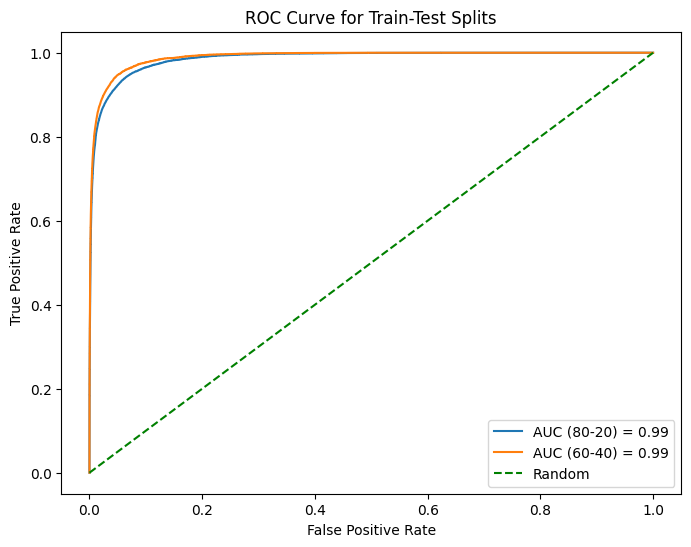

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Load 60
y_60 = np.load(PROC_DIR / "baseline_y_train_60.npy")
fusion_60 = np.load(PROC_DIR / "final_fusion_score_60.npy")

# ROC
fpr_60, tpr_60, _ = roc_curve(y_60, fusion_60)
fpr_80, tpr_80, _ = roc_curve(y_80, fusion_80)

auc_60 = roc_auc_score(y_60, fusion_60)
auc_80 = roc_auc_score(y_80, fusion_80)

plt.figure(figsize=(8,6))

plt.plot(fpr_80, tpr_80, label=f"AUC (80-20) = {auc_80:.2f}")
plt.plot(fpr_60, tpr_60, label=f"AUC (60-40) = {auc_60:.2f}")

plt.plot([0,1],[0,1],'g--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Train-Test Splits")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/final_roc.png", dpi=300)
plt.show()

In [ ]:
print("\n📁 PROCESSED FILES:")
for f in PROC_DIR.iterdir():
    print(f.name)

print("\n📁 METADATA FILES:")
for f in META_DIR.iterdir():
    print(f.name)

print("\n📁 PLOTS:")
for f in (PROJECT_DIR / "plots").iterdir():
    print(f.name)


📁 PROCESSED FILES:
X_train_60.npy
y_train_60.npy
X_test_40.npy
y_test_40.npy
X_train_80.npy
y_train_80.npy
X_test_20.npy
y_test_20.npy
X_train_60_40_smote.npy
y_train_60_40_smote.npy
X_train_80_20_smote.npy
y_train_80_20_smote.npy
lgb_60_40_train_prob.npy
lgb_60_40_test_prob.npy
lgb_80_20_train_prob.npy
lgb_80_20_test_prob.npy
X_train_60_sel.npy
X_test_40_sel.npy
X_train_80_sel.npy
X_test_20_sel.npy
AE_X_train_60.npy
AE_X_test_40.npy
AE_X_train_80.npy
AE_X_test_20.npy
baseline_X_train_60.npy
baseline_X_test_40.npy
baseline_X_train_80.npy
baseline_X_test_20.npy
baseline_y_train_60.npy
baseline_y_test_40.npy
baseline_y_train_80.npy
baseline_y_test_20.npy
smote_X_train_60.npy
smote_y_train_60.npy
smote_X_train_80.npy
smote_y_train_80.npy
ae_train_err_60.npy
ae_test_err_60.npy
ae_train_err_80.npy
ae_test_err_80.npy
baseline_ae_train_err_60.npy
baseline_ae_test_err_60.npy
baseline_ae_train_err_80.npy
baseline_ae_test_err_80.npy
baseline_gnn_train_out_60.npy
baseline_gnn_v2_out_60.npy
final

In [ ]:
import numpy as np

# 60
y_60 = np.load(PROC_DIR / "baseline_y_train_60.npy")
lgb_60 = np.load(PROC_DIR / "lgb_60_40_train_prob.npy")
ae_60  = np.load(PROC_DIR / "baseline_ae_train_err_60.npy")
gnn_60 = np.load(PROC_DIR / "baseline_gnn_v2_out_60.npy")
fusion_60 = np.load(PROC_DIR / "final_fusion_score_60.npy")

# 80
y_80 = np.load(PROC_DIR / "baseline_y_train_80.npy")
lgb_80 = np.load(PROC_DIR / "lgb_80_20_train_prob.npy")
ae_80  = np.load(PROC_DIR / "baseline_ae_train_err_80.npy")
gnn_80 = np.load(PROC_DIR / "baseline_gnn_v2_out_80.npy")
fusion_80 = np.load(PROC_DIR / "final_fusion_score_80.npy")

# Normalize AE
ae_60 = (ae_60 - ae_60.min()) / (ae_60.max() - ae_60.min())
ae_80 = (ae_80 - ae_80.min()) / (ae_80.max() - ae_80.min())

In [ ]:
from sklearn.metrics import *
import time

def full_metrics(y, prob):
    start = time.time()

    pred = (prob > 0.5).astype(int)

    auc = roc_auc_score(y, prob)

    metrics = {
        # Classification
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),

        # Core fraud metrics
        "roc_auc": auc,
        "pr_auc": average_precision_score(y, prob),
        "gini": 2*auc - 1,

        # Advanced
        "mcc": matthews_corrcoef(y, pred),
        "balanced_acc": balanced_accuracy_score(y, pred),
        "brier": brier_score_loss(y, prob),

        # Regression-style (important for paper)
        "mse": mean_squared_error(y, prob),
        "rmse": np.sqrt(mean_squared_error(y, prob)),
        "mae": mean_absolute_error(y, prob),
        "r2": r2_score(y, prob),

        # Normalized RMSE
        "nrmse": np.sqrt(mean_squared_error(y, prob)) / (y.max() - y.min()),

        # MAPE (safe)
        "mape": np.mean(np.abs((y - prob) / (y + 1e-6))),

        # Time
        "time_sec": time.time() - start
    }

    return metrics

In [ ]:
models_60 = {
    "LGB": lgb_60,
    "AE": ae_60,
    "GNN": gnn_60,
    "Fusion": fusion_60
}

models_80 = {
    "LGB": lgb_80,
    "AE": ae_80,
    "GNN": gnn_80,
    "Fusion": fusion_80
}

results_60 = {k: full_metrics(y_60, v) for k,v in models_60.items()}
results_80 = {k: full_metrics(y_80, v) for k,v in models_80.items()}

In [ ]:
def print_results(results, title):
    print(f"\n===== {title} =====")
    for model, vals in results.items():
        print(f"\n🔹 {model}")
        for k,v in vals.items():
            print(f"{k}: {v:.4f}")

print_results(results_60, "60/40 RESULTS")
print_results(results_80, "80/20 RESULTS")


===== 60/40 RESULTS =====

🔹 LGB
accuracy: 0.9550
precision: 0.6128
recall: 0.9433
f1: 0.7429
roc_auc: 0.9905
pr_auc: 0.9193
gini: 0.9810
mcc: 0.7397
balanced_acc: 0.9496
brier: 0.0420
mse: 0.0420
rmse: 0.2050
mae: 0.1332
r2: 0.3449
nrmse: 0.2050
mape: 124090.8564
time_sec: 0.1472

🔹 AE
accuracy: 0.9311
precision: 0.0000
recall: 0.0000
f1: 0.0000
roc_auc: 0.7541
pr_auc: 0.2597
gini: 0.5082
mcc: -0.0006
balanced_acc: 0.5000
brier: 0.0688
mse: 0.0688
rmse: 0.2624
mae: 0.0689
r2: -0.0735
nrmse: 0.2624
mape: 64.2302
time_sec: 0.1383

🔹 GNN
accuracy: 0.7430
precision: 0.1592
recall: 0.6378
f1: 0.2548
roc_auc: 0.7562
pr_auc: 0.2634
gini: 0.5125
mcc: 0.2201
balanced_acc: 0.6943
brier: 0.1834
mse: 0.1834
rmse: 0.4282
mae: 0.3837
r2: -1.8592
nrmse: 0.4282
mape: 356046.4142
time_sec: 0.1443

🔹 Fusion
accuracy: 0.9737
precision: 0.7711
recall: 0.8800
f1: 0.8220
roc_auc: 0.9894
pr_auc: 0.9067
gini: 0.9788
mcc: 0.8099
balanced_acc: 0.9303
brier: 0.0371
mse: 0.0371
rmse: 0.1926
mae: 0.1454
r2: 0.42

In [ ]:
import json

with open(META_DIR / "final_results_60.json", "w") as f:
    json.dump(results_60, f, indent=2)

with open(META_DIR / "final_results_80.json", "w") as f:
    json.dump(results_80, f, indent=2)

print("All metrics saved ✅")

All metrics saved ✅


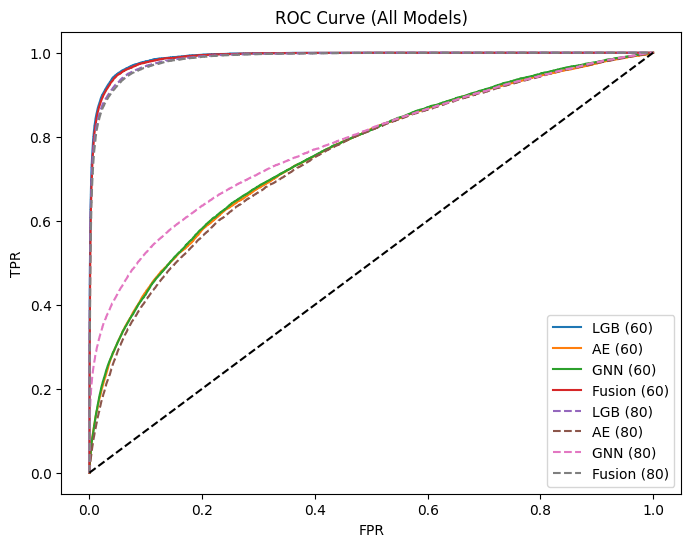

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, prob in models_60.items():
    fpr, tpr, _ = roc_curve(y_60, prob)
    plt.plot(fpr, tpr, label=f"{name} (60)")

for name, prob in models_80.items():
    fpr, tpr, _ = roc_curve(y_80, prob)
    plt.plot(fpr, tpr, linestyle="--", label=f"{name} (80)")

plt.plot([0,1],[0,1],'k--')

plt.title("ROC Curve (All Models)")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/final_roc_all_models.png", dpi=300)
plt.show()

/tmp/ipykernel_18655/3483336782.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(PROJECT_DIR / "plots/final_pr_all_models.png", dpi=300)


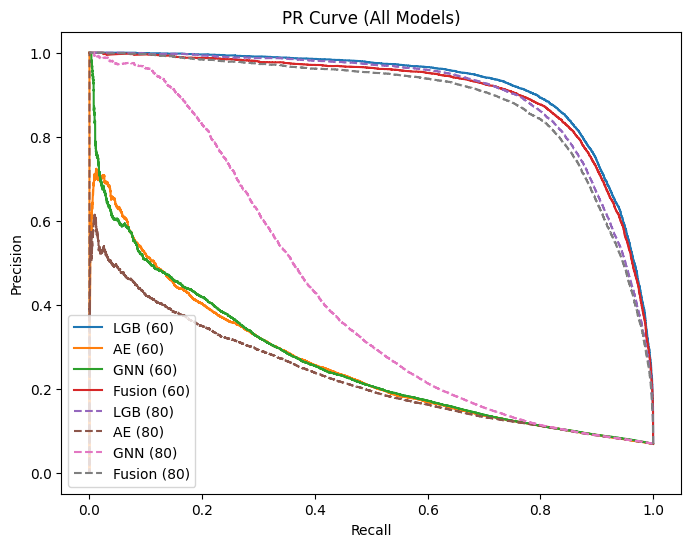

In [ ]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(8,6))

for name, prob in models_60.items():
    prec, rec, _ = precision_recall_curve(y_60, prob)
    plt.plot(rec, prec, label=f"{name} (60)")

for name, prob in models_80.items():
    prec, rec, _ = precision_recall_curve(y_80, prob)
    plt.plot(rec, prec, linestyle="--", label=f"{name} (80)")

plt.title("PR Curve (All Models)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/final_pr_all_models.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import time

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# Load
y_60 = np.load(PROC_DIR / "baseline_y_train_60.npy")
fusion_60 = np.load(PROC_DIR / "final_fusion_score_60.npy")

y_80 = np.load(PROC_DIR / "baseline_y_train_80.npy")
fusion_80 = np.load(PROC_DIR / "final_fusion_score_80.npy")

In [ ]:
start_60 = time.time()
auc_60 = roc_auc_score(y_60, fusion_60)
pr_60  = average_precision_score(y_60, fusion_60)
time_60 = time.time() - start_60

start_80 = time.time()
auc_80 = roc_auc_score(y_80, fusion_80)
pr_80  = average_precision_score(y_80, fusion_80)
time_80 = time.time() - start_80

print("60/40 → AUC:", auc_60, " PR:", pr_60, " Time:", time_60)
print("80/20 → AUC:", auc_80, " PR:", pr_80, " Time:", time_80)

60/40 → AUC: 0.9894181910482784  PR: 0.906727951575553  Time: 0.09519243240356445
80/20 → AUC: 0.9859314170533182  PR: 0.886547322969782  Time: 0.11131167411804199


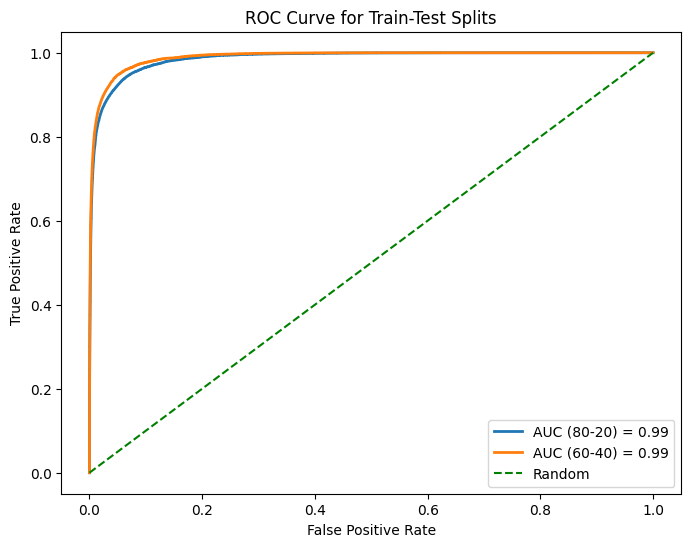

In [ ]:
import matplotlib.pyplot as plt

fpr_60, tpr_60, _ = roc_curve(y_60, fusion_60)
fpr_80, tpr_80, _ = roc_curve(y_80, fusion_80)

plt.figure(figsize=(8,6))

plt.plot(fpr_80, tpr_80, label=f"AUC (80-20) = {auc_80:.2f}", linewidth=2)
plt.plot(fpr_60, tpr_60, label=f"AUC (60-40) = {auc_60:.2f}", linewidth=2)

plt.plot([0,1],[0,1],'g--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Train-Test Splits")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/final_fusion_roc.png", dpi=300)
plt.show()

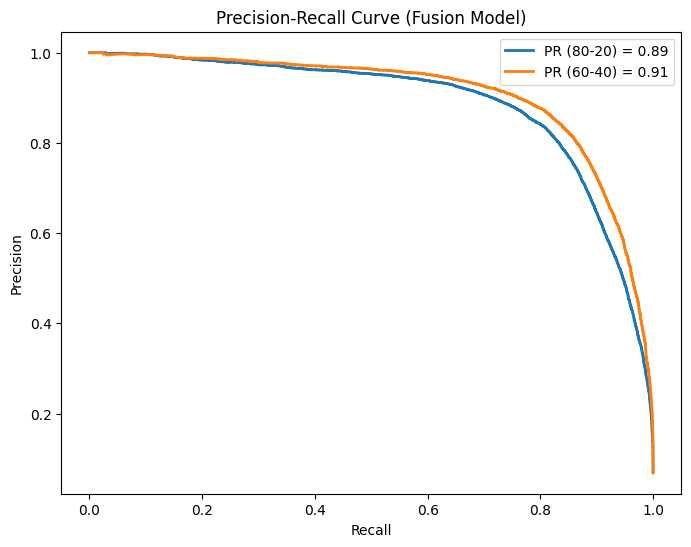

In [ ]:
prec_60, rec_60, _ = precision_recall_curve(y_60, fusion_60)
prec_80, rec_80, _ = precision_recall_curve(y_80, fusion_80)

plt.figure(figsize=(8,6))

plt.plot(rec_80, prec_80, label=f"PR (80-20) = {pr_80:.2f}", linewidth=2)
plt.plot(rec_60, prec_60, label=f"PR (60-40) = {pr_60:.2f}", linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Fusion Model)")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/final_fusion_pr.png", dpi=300)
plt.show()

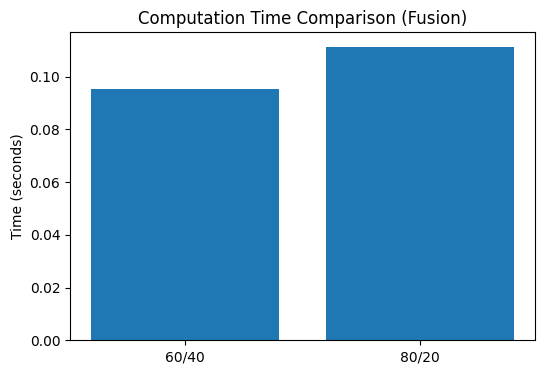

In [ ]:
plt.figure(figsize=(6,4))

labels = ["60/40", "80/20"]
times = [time_60, time_80]

plt.bar(labels, times)

plt.title("Computation Time Comparison (Fusion)")
plt.ylabel("Time (seconds)")

plt.savefig(PROJECT_DIR / "plots/fusion_time.png", dpi=300)
plt.show()

In [ ]:
import numpy as np
import json
import time
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

print("\n🚀 STARTING FINAL CHECK + FIX\n")

# -----------------------------
# LOAD DATA
# -----------------------------
y_60 = np.load(PROC_DIR / "baseline_y_train_60.npy")
y_80 = np.load(PROC_DIR / "baseline_y_train_80.npy")

lgb_60 = np.load(PROC_DIR / "lgb_60_40_train_prob.npy")
lgb_80 = np.load(PROC_DIR / "lgb_80_20_train_prob.npy")

ae_60 = np.load(PROC_DIR / "baseline_ae_train_err_60.npy")
ae_80 = np.load(PROC_DIR / "baseline_ae_train_err_80.npy")

gnn_60 = np.load(PROC_DIR / "baseline_gnn_v2_out_60.npy")
gnn_80 = np.load(PROC_DIR / "baseline_gnn_v2_out_80.npy")

# Normalize AE
ae_60 = (ae_60 - ae_60.min()) / (ae_60.max() - ae_60.min())
ae_80 = (ae_80 - ae_80.min()) / (ae_80.max() - ae_80.min())

# -----------------------------
# FUSION (REBUILD IF NEEDED)
# -----------------------------
w1, w2, w3 = 0.7, 0.2, 0.1

fusion_60 = w1*lgb_60 + w2*ae_60 + w3*gnn_60
fusion_80 = w1*lgb_80 + w2*ae_80 + w3*gnn_80

np.save(PROC_DIR / "final_fusion_score_60.npy", fusion_60)
np.save(PROC_DIR / "final_fusion_score_80.npy", fusion_80)

print("✅ Fusion ensured")

# -----------------------------
# METRICS
# -----------------------------
start = time.time()
auc_60 = roc_auc_score(y_60, fusion_60)
pr_60  = average_precision_score(y_60, fusion_60)
time_60 = time.time() - start

start = time.time()
auc_80 = roc_auc_score(y_80, fusion_80)
pr_80  = average_precision_score(y_80, fusion_80)
time_80 = time.time() - start

# Save summary
summary = {
    "60_40": {"auc": float(auc_60), "pr": float(pr_60), "time": float(time_60)},
    "80_20": {"auc": float(auc_80), "pr": float(pr_80), "time": float(time_80)},
    "weights": {"lgb": 0.7, "ae": 0.2, "gnn": 0.1}
}

with open(META_DIR / "final_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("✅ Metrics saved")

# -----------------------------
# ROC GRAPH (FINAL)
# -----------------------------
fpr_60, tpr_60, _ = roc_curve(y_60, fusion_60)
fpr_80, tpr_80, _ = roc_curve(y_80, fusion_80)

plt.figure(figsize=(8,6))
plt.plot(fpr_80, tpr_80, label=f"AUC (80-20) = {auc_80:.2f}")
plt.plot(fpr_60, tpr_60, label=f"AUC (60-40) = {auc_60:.2f}")
plt.plot([0,1],[0,1],'g--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Fusion)")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/final_fusion_roc.png", dpi=300)
plt.close()

print("✅ ROC saved")

# -----------------------------
# PR GRAPH
# -----------------------------
prec_60, rec_60, _ = precision_recall_curve(y_60, fusion_60)
prec_80, rec_80, _ = precision_recall_curve(y_80, fusion_80)

plt.figure(figsize=(8,6))
plt.plot(rec_80, prec_80, label=f"80-20 (PR={pr_80:.2f})")
plt.plot(rec_60, prec_60, label=f"60-40 (PR={pr_60:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (Fusion)")
plt.legend()

plt.savefig(PROJECT_DIR / "plots/final_fusion_pr.png", dpi=300)
plt.close()

print("✅ PR saved")

# -----------------------------
# TIME GRAPH
# -----------------------------
plt.figure(figsize=(6,4))
plt.bar(["60/40", "80/20"], [time_60, time_80])

plt.title("Computation Time (Fusion)")
plt.ylabel("Seconds")

plt.savefig(PROJECT_DIR / "plots/fusion_time.png", dpi=300)
plt.close()

print("✅ Time graph saved")

# -----------------------------
# FINAL FILE CHECK
# -----------------------------
print("\n📁 FINAL CHECK:")
required = [
    "final_fusion_score_60.npy",
    "final_fusion_score_80.npy",
]

for f in required:
    print(f, "✅" if (PROC_DIR / f).exists() else "❌")

print("\n📊 RESULTS:")
print("60 → AUC:", round(auc_60,4), "PR:", round(pr_60,4))
print("80 → AUC:", round(auc_80,4), "PR:", round(pr_80,4))

print("\n🎉 EVERYTHING COMPLETE")


🚀 STARTING FINAL CHECK + FIX

✅ Fusion ensured
✅ Metrics saved
✅ ROC saved
✅ PR saved
✅ Time graph saved

📁 FINAL CHECK:
final_fusion_score_60.npy ✅
final_fusion_score_80.npy ✅

📊 RESULTS:
60 → AUC: 0.9894 PR: 0.9067
80 → AUC: 0.9859 PR: 0.8865

🎉 EVERYTHING COMPLETE


In [ ]:
from sklearn.metrics import log_loss, cohen_kappa_score

def extra_metrics(y, prob):
    pred = (prob > 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()

    # Specificity
    specificity = tn / (tn + fp + 1e-6)

    # G-Mean
    recall = tp / (tp + fn + 1e-6)
    gmean = np.sqrt(recall * specificity)

    return {
        "log_loss": log_loss(y, prob),
        "specificity": specificity,
        "gmean": gmean,
        "kappa": cohen_kappa_score(y, pred)
    }

In [ ]:
extra_60 = extra_metrics(y_60, fusion_60)
extra_80 = extra_metrics(y_80, fusion_80)

print("\n60/40 EXTRA METRICS")
for k,v in extra_60.items():
    print(k, round(v,4))

print("\n80/20 EXTRA METRICS")
for k,v in extra_80.items():
    print(k, round(v,4))


60/40 EXTRA METRICS
log_loss 0.1717
specificity 0.9807
gmean 0.929
kappa 0.8079

80/20 EXTRA METRICS
log_loss 0.1778
specificity 0.9781
gmean 0.9189
kappa 0.7834


In [ ]:
from sklearn.metrics import *
from sklearn.metrics import log_loss, cohen_kappa_score
import numpy as np
import time

def full_metrics(y, prob):
    start = time.time()

    pred = (prob > 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()

    auc = roc_auc_score(y, prob)

    # Specificity
    specificity = tn / (tn + fp + 1e-6)

    # Recall
    recall = tp / (tp + fn + 1e-6)

    # G-Mean
    gmean = np.sqrt(recall * specificity)

    metrics = {
        # Classification
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall,
        "specificity": specificity,
        "f1": f1_score(y, pred),

        # Core fraud metrics
        "roc_auc": auc,
        "pr_auc": average_precision_score(y, prob),
        "gini": 2*auc - 1,

        # Advanced
        "mcc": matthews_corrcoef(y, pred),
        "kappa": cohen_kappa_score(y, pred),
        "gmean": gmean,
        "balanced_acc": balanced_accuracy_score(y, pred),
        "brier": brier_score_loss(y, prob),
        "log_loss": log_loss(y, prob),

        # Regression-style
        "mse": mean_squared_error(y, prob),
        "rmse": np.sqrt(mean_squared_error(y, prob)),
        "mae": mean_absolute_error(y, prob),
        "r2": r2_score(y, prob),
        "nrmse": np.sqrt(mean_squared_error(y, prob)) / (y.max() - y.min()),
        "mape": np.mean(np.abs((y - prob) / (y + 1e-6))),

        # Time
        "time_sec": time.time() - start
    }

    return metrics

In [ ]:
results_60 = {k: full_metrics(y_60, v) for k,v in models_60.items()}
results_80 = {k: full_metrics(y_80, v) for k,v in models_80.items()}

In [ ]:
def print_results(results, title):
    print(f"\n===== {title} =====")
    for model, vals in results.items():
        print(f"\n🔹 {model}")
        for k,v in vals.items():
            print(f"{k}: {v:.4f}")

print_results(results_60, "60/40 RESULTS")
print_results(results_80, "80/20 RESULTS")


===== 60/40 RESULTS =====

🔹 LGB
accuracy: 0.9550
precision: 0.6128
recall: 0.9433
specificity: 0.9559
f1: 0.7429
roc_auc: 0.9905
pr_auc: 0.9193
gini: 0.9810
mcc: 0.7397
kappa: 0.7195
gmean: 0.9496
balanced_acc: 0.9496
brier: 0.0420
log_loss: 0.1694
mse: 0.0420
rmse: 0.2050
mae: 0.1332
r2: 0.3449
nrmse: 0.2050
mape: 124090.8564
time_sec: 0.1776

🔹 AE
accuracy: 0.9311
precision: 0.0000
recall: 0.0000
specificity: 1.0000
f1: 0.0000
roc_auc: 0.7541
pr_auc: 0.2597
gini: 0.5082
mcc: -0.0006
kappa: -0.0000
gmean: 0.0000
balanced_acc: 0.5000
brier: 0.0688
log_loss: 0.6345
mse: 0.0688
rmse: 0.2624
mae: 0.0689
r2: -0.0735
nrmse: 0.2624
mape: 64.2302
time_sec: 0.1608

🔹 GNN
accuracy: 0.7430
precision: 0.1592
recall: 0.6378
specificity: 0.7508
f1: 0.2548
roc_auc: 0.7562
pr_auc: 0.2634
gini: 0.5125
mcc: 0.2201
kappa: 0.1624
gmean: 0.6920
balanced_acc: 0.6943
brier: 0.1834
log_loss: 0.5586
mse: 0.1834
rmse: 0.4282
mae: 0.3837
r2: -1.8592
nrmse: 0.4282
mape: 356046.4142
time_sec: 0.1636

🔹 Fusion
a

In [ ]:
def print_fusion_only(y_60, fusion_60, y_80, fusion_80):

    m60 = full_metrics(y_60, fusion_60)
    m80 = full_metrics(y_80, fusion_80)

    print("\n🔥 FINAL FUSION RESULTS\n")

    print("====== 60/40 ======")
    for k,v in m60.items():
        print(f"{k}: {v:.4f}")

    print("\n====== 80/20 ======")
    for k,v in m80.items():
        print(f"{k}: {v:.4f}")

print_fusion_only(y_60, fusion_60, y_80, fusion_80)


🔥 FINAL FUSION RESULTS

====== 60/40 ======
accuracy: 0.9737
precision: 0.7711
recall: 0.8800
specificity: 0.9807
f1: 0.8220
roc_auc: 0.9894
pr_auc: 0.9067
gini: 0.9788
mcc: 0.8099
kappa: 0.8079
gmean: 0.9290
balanced_acc: 0.9303
brier: 0.0371
log_loss: 0.1717
mse: 0.0371
rmse: 0.1926
mae: 0.1454
r2: 0.4216
nrmse: 0.1926
mape: 122481.0876
time_sec: 0.1756

====== 80/20 ======
accuracy: 0.9702
precision: 0.7444
recall: 0.8633
specificity: 0.9781
f1: 0.7994
roc_auc: 0.9859
pr_auc: 0.8865
gini: 0.9719
mcc: 0.7859
kappa: 0.7834
gmean: 0.9189
balanced_acc: 0.9207
brier: 0.0393
log_loss: 0.1778
mse: 0.0393
rmse: 0.1982
mae: 0.1495
r2: 0.3877
nrmse: 0.1982
mape: 126411.9709
time_sec: 0.2234


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Metric": list(full_metrics(y_60, fusion_60).keys()),
    "60/40": list(full_metrics(y_60, fusion_60).values()),
    "80/20": list(full_metrics(y_80, fusion_80).values())
})

df

,Metric,60/40,80/20
0,accuracy,0.973744,0.970167
1,precision,0.771134,0.744392
2,recall,0.879981,0.863279
3,specificity,0.980680,0.978073
4,f1,0.821969,0.799440
5,roc_auc,0.989418,0.985931
6,pr_auc,0.906728,0.886547
7,gini,0.978836,0.971863
8,mcc,0.809915,0.785930
9,kappa,0.807863,0.783420


60/40 Confusion Matrix:
 [[164364   3238]
 [  1488  10910]]

80/20 Confusion Matrix:
 [[218570   4900]
 [  2260  14270]]


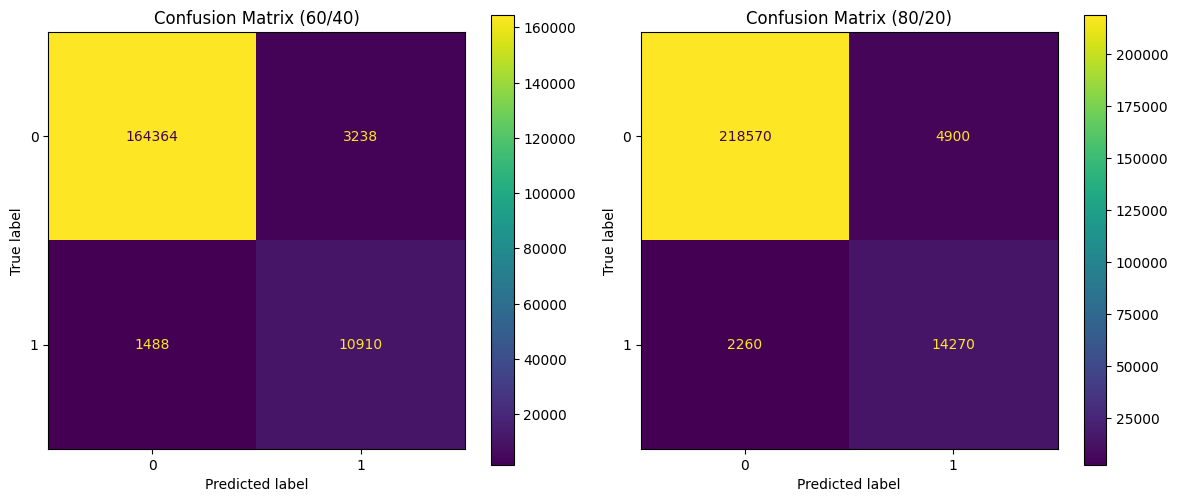

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from pathlib import Path # Import Path for PROC_DIR

# Define PROC_DIR for this cell
PROJECT_DIR = Path('/content/drive/MyDrive/ieee_cis_fraud_project')
PROC_DIR = PROJECT_DIR / 'processed'

# -----------------------------
# LOAD DATA (same as your code)
# -----------------------------
y_60 = np.load(PROC_DIR / "baseline_y_train_60.npy")
fusion_60 = np.load(PROC_DIR / "final_fusion_score_60.npy")

y_80 = np.load(PROC_DIR / "baseline_y_train_80.npy")
fusion_80 = np.load(PROC_DIR / "final_fusion_score_80.npy")

# -----------------------------
# CONVERT PROB → PREDICTION
# -----------------------------
threshold = 0.5   # you can tune later

pred_60 = (fusion_60 > threshold).astype(int)
pred_80 = (fusion_80 > threshold).astype(int)

# -----------------------------
# CONFUSION MATRICES
# -----------------------------
cm_60 = confusion_matrix(y_60, pred_60)
cm_80 = confusion_matrix(y_80, pred_80)

print("60/40 Confusion Matrix:\n", cm_60)
print("\n80/20 Confusion Matrix:\n", cm_80)

# -----------------------------
# PLOT
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay(cm_60).plot(ax=ax[0])
ax[0].set_title("Confusion Matrix (60/40)")

ConfusionMatrixDisplay(cm_80).plot(ax=ax[1])
ax[1].set_title("Confusion Matrix (80/20)")

plt.tight_layout()
plt.show()

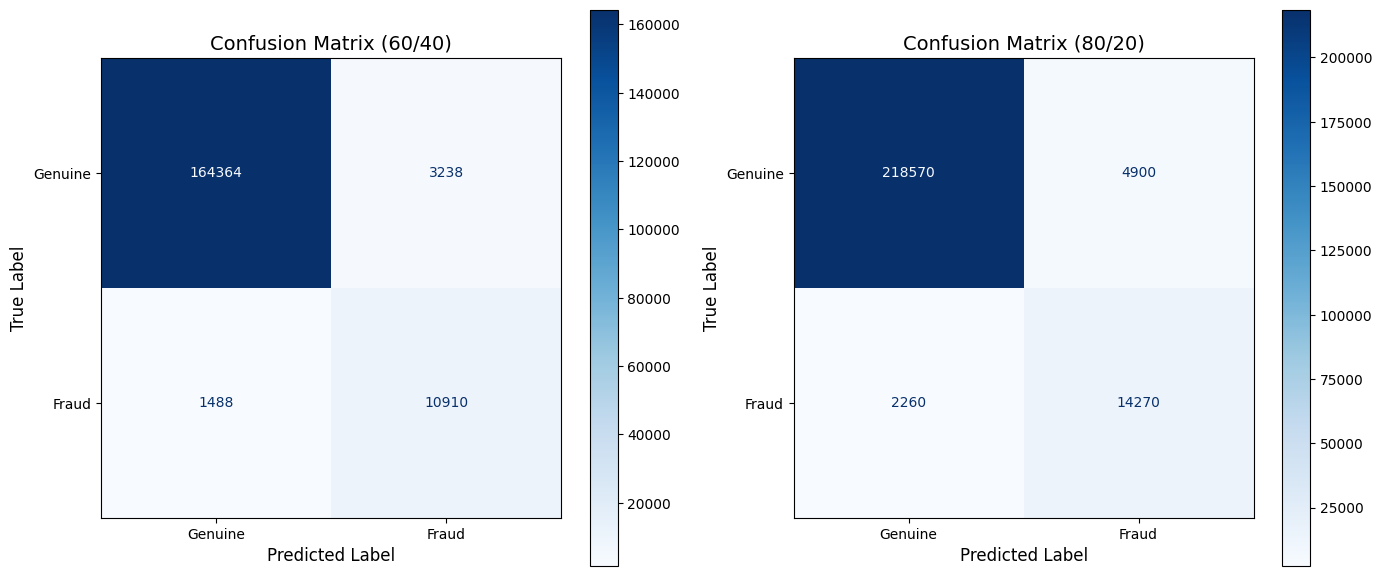

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load
y_60 = np.load(PROC_DIR / "baseline_y_train_60.npy")
fusion_60 = np.load(PROC_DIR / "final_fusion_score_60.npy")

y_80 = np.load(PROC_DIR / "baseline_y_train_80.npy")
fusion_80 = np.load(PROC_DIR / "final_fusion_score_80.npy")

# Predictions
threshold = 0.5
pred_60 = (fusion_60 > threshold).astype(int)
pred_80 = (fusion_80 > threshold).astype(int)

# Confusion matrices
cm_60 = confusion_matrix(y_60, pred_60)
cm_80 = confusion_matrix(y_80, pred_80)

# -----------------------------
# PLOT (BLUE STYLE)
# -----------------------------
fig, ax = plt.subplots(1, 2, figsize=(14,6))

disp1 = ConfusionMatrixDisplay(cm_60, display_labels=["Genuine", "Fraud"])
disp1.plot(ax=ax[0], cmap="Blues", colorbar=True)
ax[0].set_title("Confusion Matrix (60/40)", fontsize=14)

disp2 = ConfusionMatrixDisplay(cm_80, display_labels=["Genuine", "Fraud"])
disp2.plot(ax=ax[1], cmap="Blues", colorbar=True)
ax[1].set_title("Confusion Matrix (80/20)", fontsize=14)

# Improve layout
for a in ax:
    a.set_xlabel("Predicted Label", fontsize=12)
    a.set_ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.show()